## Install & Import dependencies | Dataset creation

In [ ]:
!pip install "ray[tune]" torch torchvision mlflow pytorch-forecasting onnxscript optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 693.4/693.4 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.1/18.1 MB 113.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.1/133.1 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.0/225.0 kB 22.6 MB/s eta 0:00:00
  Attempting uninstall: werkzeug
    Found existing installation: Werkzeug 2.2.3
    Uninstalling Werkzeug-2.2.3:
      Successfully uninstalled Werkzeug-2.2.3


In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
from statsmodels.tsa.stattools import adfuller

tickers = [
  "EURUSD=X",
  "GBPUSD=X",
  "USDJPY=X",
  "USDCHF=X",
  "USDCAD=X",
  "AUDUSD=X",
  "NZDUSD=X",
  "EURMAD=X",
  "EURRUB=X",
  "RUBUSD=X"
]

In [3]:
df = yf.download(
    tickers,
    start = "2010-01-01",
    end = "2025-12-24",
    interval = "1d",
    group_by = "ticker",
    threads=True
)

/tmp/ipython-input-819092093.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(
[*********************100%***********************]  10 of 10 completed


In [4]:
df.tail()

Ticker      RUBUSD=X                                       NZDUSD=X            \
Price           Open      High       Low     Close Volume      Open      High   
Date                                                                            
2025-12-17  0.012651  0.012653  0.012370  0.012652    0.0  0.578700  0.579462   
2025-12-18  0.012423  0.012529  0.012421  0.012423    0.0  0.576981  0.578861   
2025-12-19  0.012514  0.012519  0.012327  0.012513    0.0  0.577581  0.578400   
2025-12-22  0.012558  0.012715  0.012557  0.012554    0.0  0.575709  0.580050   
2025-12-23  0.012691  0.012823  0.012689  0.012691    0.0  0.579650  0.584400   

Ticker                                 ...  GBPUSD=X                      \
Price            Low     Close Volume  ...      Open      High       Low   
Date                                   ...                                 
2025-12-17  0.576861  0.578600    0.0  ...  1.342624  1.342642  1.331363   
2025-12-18  0.575579  0.577300    0.0  ...  1.337453  1.344538  1.334241   
2025-12-19  0.573720  0.577611    0.0  ...  1.338419  1.338742  1.335773   
2025-12-22  0.575709  0.575490    0.0  ...  1.338007  1.346729  1.338007   
2025-12-23  0.579650  0.579771    0.0  ...  1.346892  1.352064  1.346892   

Ticker                      USDCHF=X                                    
Price          Close Volume     Open     High      Low    Close Volume  
Date                                                                    
2025-12-17  1.342500    0.0  0.79523  0.79869  0.79350  0.79520    0.0  
2025-12-18  1.337460    0.0  0.79517  0.79657  0.79290  0.79520    0.0  
2025-12-19  1.338539    0.0  0.79406  0.79619  0.79390  0.79401    0.0  
2025-12-22  1.337703    0.0  0.79536  0.79538  0.79190  0.79583    0.0  
2025-12-23  1.346990    0.0  0.79149  0.79149  0.78673  0.79143    0.0  

[5 rows x 50 columns]

In [5]:
df["NZDUSD=X"]

Price,Open,High,Low,Close,Volume
Date,,,,,
2010-01-01,0.726322,0.726322,0.724480,0.724480,0.0
2010-01-04,0.723589,0.735186,0.719994,0.734214,0.0
2010-01-05,0.734700,0.739044,0.732279,0.733783,0.0
2010-01-06,0.733783,0.738880,0.730834,0.738007,0.0
2010-01-07,0.738225,0.742611,0.731422,0.732708,0.0
...,...,...,...,...,...
2025-12-17,0.578700,0.579462,0.576861,0.578600,0.0
2025-12-18,0.576981,0.578861,0.575579,0.577300,0.0
2025-12-19,0.577581,0.578400,0.573720,0.577611,0.0


## Exploratory Data Analysis

In [6]:
for ticker in tickers:
  print(df[ticker].info)

<bound method DataFrame.info of Price           Open      High       Low     Close  Volume
Date                                                      
2010-01-01  1.432706  1.440196  1.432706  1.438994     0.0
2010-01-04  1.431004  1.445191  1.426208  1.442398     0.0
2010-01-05  1.442710  1.448310  1.435194  1.436596     0.0
2010-01-06  1.436596  1.443460  1.429123  1.440403     0.0
2010-01-07  1.440300  1.444481  1.430206  1.431803     0.0
...              ...       ...       ...       ...     ...
2025-12-17  1.174964  1.175793  1.170453  1.174950     0.0
2025-12-18  1.174219  1.175890  1.171344  1.174233     0.0
2025-12-19  1.172539  1.173750  1.170412  1.172567     0.0
2025-12-22  1.171084  1.177024  1.171084  1.170809     0.0
2025-12-23  1.176443  1.180359  1.176429  1.176595     0.0

[4163 rows x 5 columns]>
<bound method DataFrame.info of Price           Open      High       Low     Close  Volume
Date                                                      
2010-01-01  1.618202  1.6

In [7]:
df.dtypes

Ticker    Price 
RUBUSD=X  Open      float64
          High      float64
          Low       float64
          Close     float64
          Volume    float64
NZDUSD=X  Open      float64
          High      float64
          Low       float64
          Close     float64
          Volume    float64
EURRUB=X  Open      float64
          High      float64
          Low       float64
          Close     float64
          Volume    float64
USDCAD=X  Open      float64
          High      float64
          Low       float64
          Close     float64
          Volume    float64
EURMAD=X  Open      float64
          High      float64
          Low       float64
          Close     float64
          Volume    float64
AUDUSD=X  Open      float64
          High      float64
          Low       float64
          Close     float64
          Volume    float64
USDJPY=X  Open      float64
          High      float64
          Low       float64
          Close     float64
          Volume    float64
EURUSD=X  Open      float64
          High      float64
          Low       float64
          Close     float64
          Volume    float64
GBPUSD=X  Open      float64
          High      float64
          Low       float64
          Close     float64
          Volume    float64
USDCHF=X  Open      float64
          High      float64
          Low       float64
          Close     float64
          Volume    float64
dtype: object

In [8]:
print(f"Shape: {df.shape}")
print(f"Statistical Summary: {df.describe()}")

Shape: (4163, 50)
Statistical Summary: Ticker     RUBUSD=X                                                 \
Price          Open         High          Low        Close  Volume   
count   4160.000000  4160.000000  4160.000000  4160.000000  4160.0   
mean       0.019678     0.019797     0.019543     0.020047     0.0   
std        0.008388     0.008395     0.008363     0.023102     0.0   
min        0.007181     0.007437     0.006463     0.007196     0.0   
25%        0.013462     0.013554     0.013367     0.013455     0.0   
50%        0.015814     0.015921     0.015719     0.015806     0.0   
75%        0.030062     0.030154     0.029974     0.030116     0.0   
max        0.036826     0.036828     0.036512     1.396258     0.0   

Ticker     NZDUSD=X                                                 ...  \
Price          Open         High          Low        Close  Volume  ...   
count   4160.000000  4160.000000  4160.000000  4160.000000  4160.0  ...   
mean       0.702103     0.705607   

In [9]:
# Identify missing values:
print(df.isnull().sum())

Ticker    Price 
RUBUSD=X  Open      3
          High      3
          Low       3
          Close     3
          Volume    3
NZDUSD=X  Open      3
          High      3
          Low       3
          Close     3
          Volume    3
EURRUB=X  Open      2
          High      2
          Low       2
          Close     2
          Volume    2
USDCAD=X  Open      4
          High      4
          Low       4
          Close     4
          Volume    4
EURMAD=X  Open      5
          High      5
          Low       5
          Close     5
          Volume    5
AUDUSD=X  Open      4
          High      4
          Low       4
          Close     4
          Volume    4
USDJPY=X  Open      3
          High      3
          Low       3
          Close     3
          Volume    3
EURUSD=X  Open      3
          High      3
          Low       3
          Close     3
          Volume    3
GBPUSD=X  Open      3
          High      3
          Low       3
          Close     3
          Volum

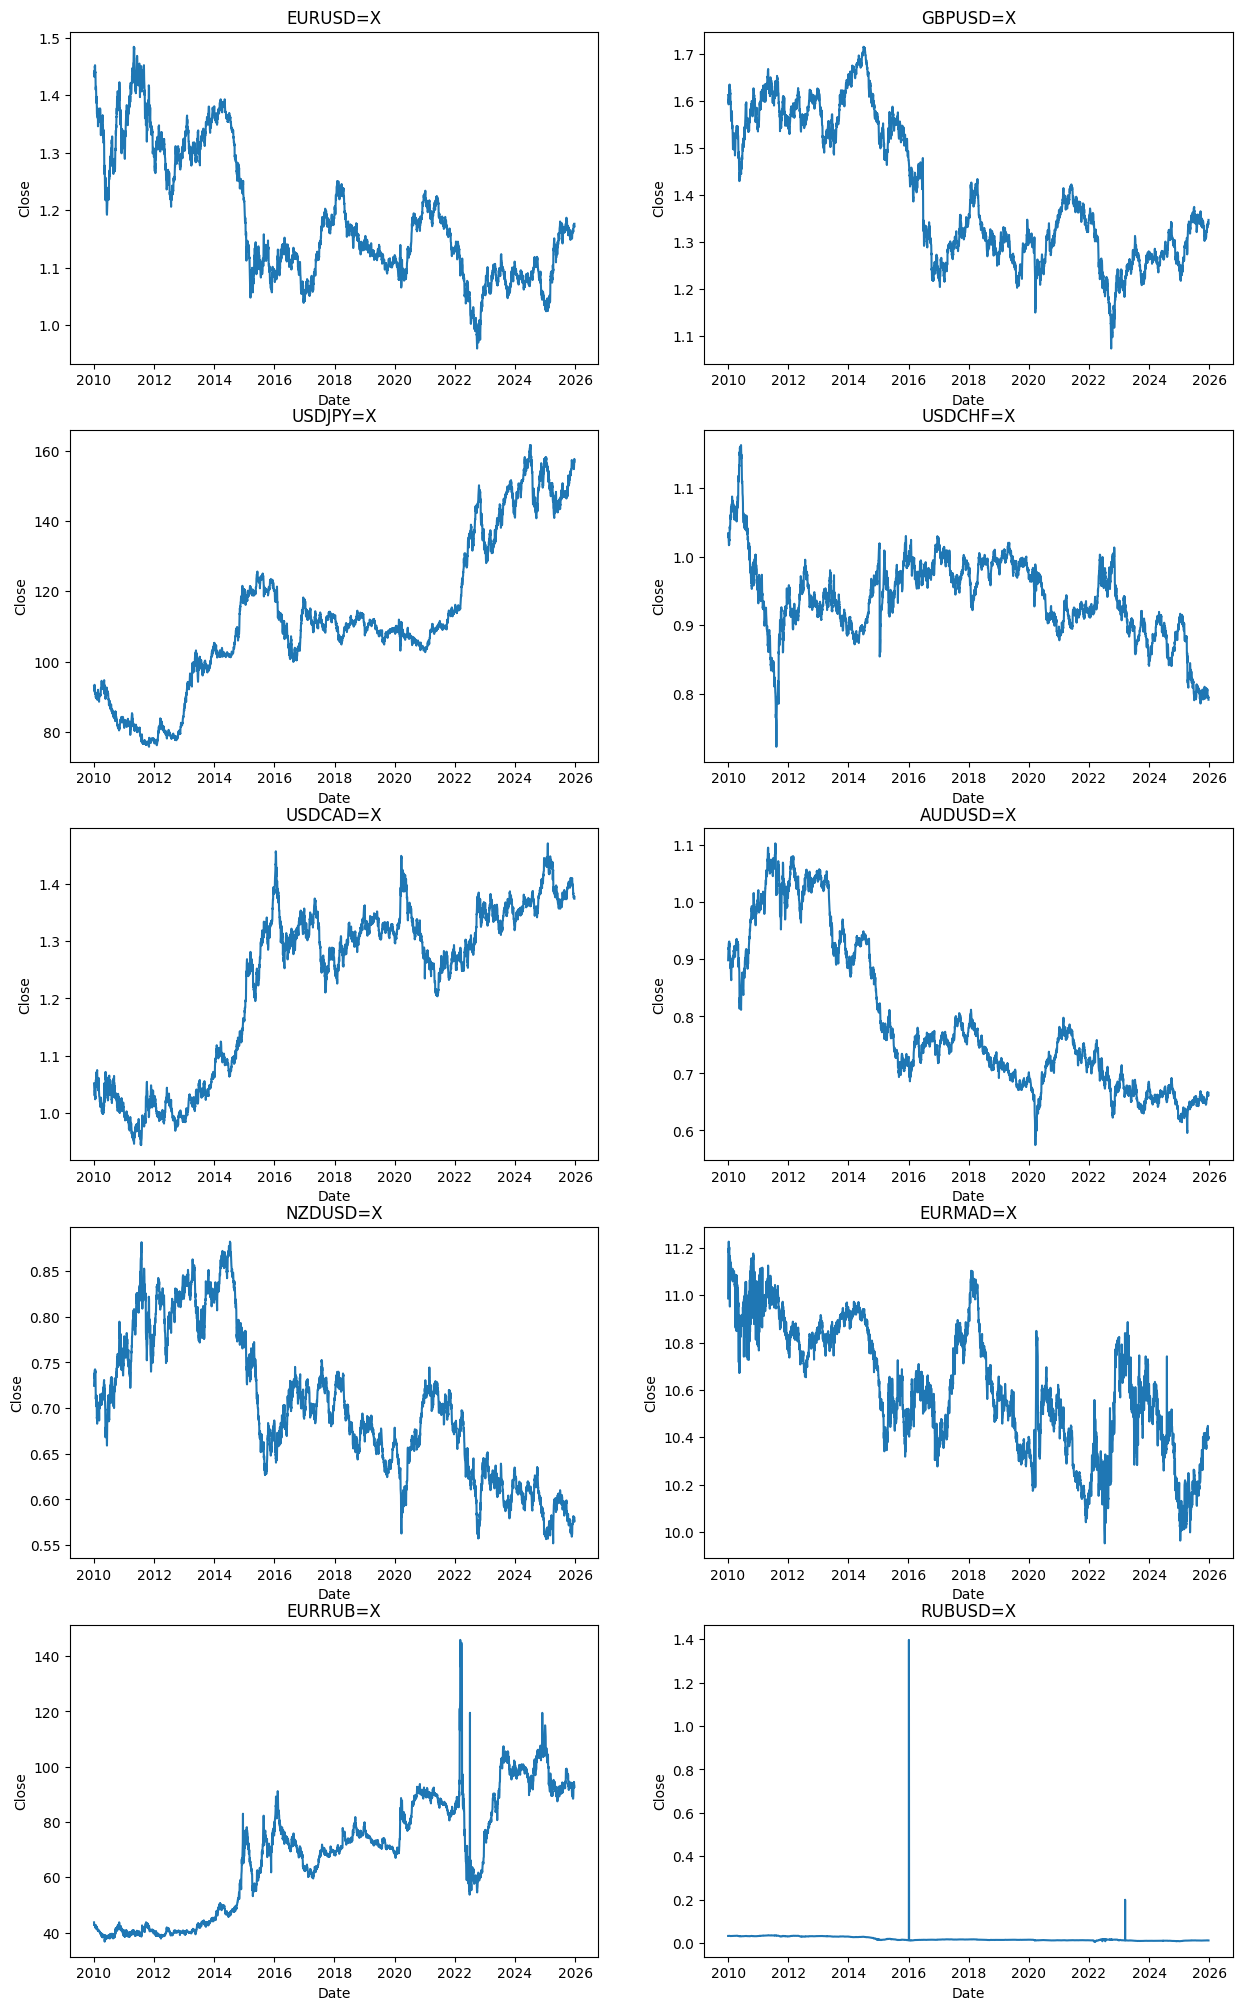

In [10]:
fig = plt.figure(figsize=(15, 25))
for ticker in tickers:
  ax = fig.add_subplot(5, 2, tickers.index(ticker)+1)
  sns.lineplot(x=df.index, y=df[ticker]["Close"], ax=ax)
  ax.set_title(ticker)
plt.show()

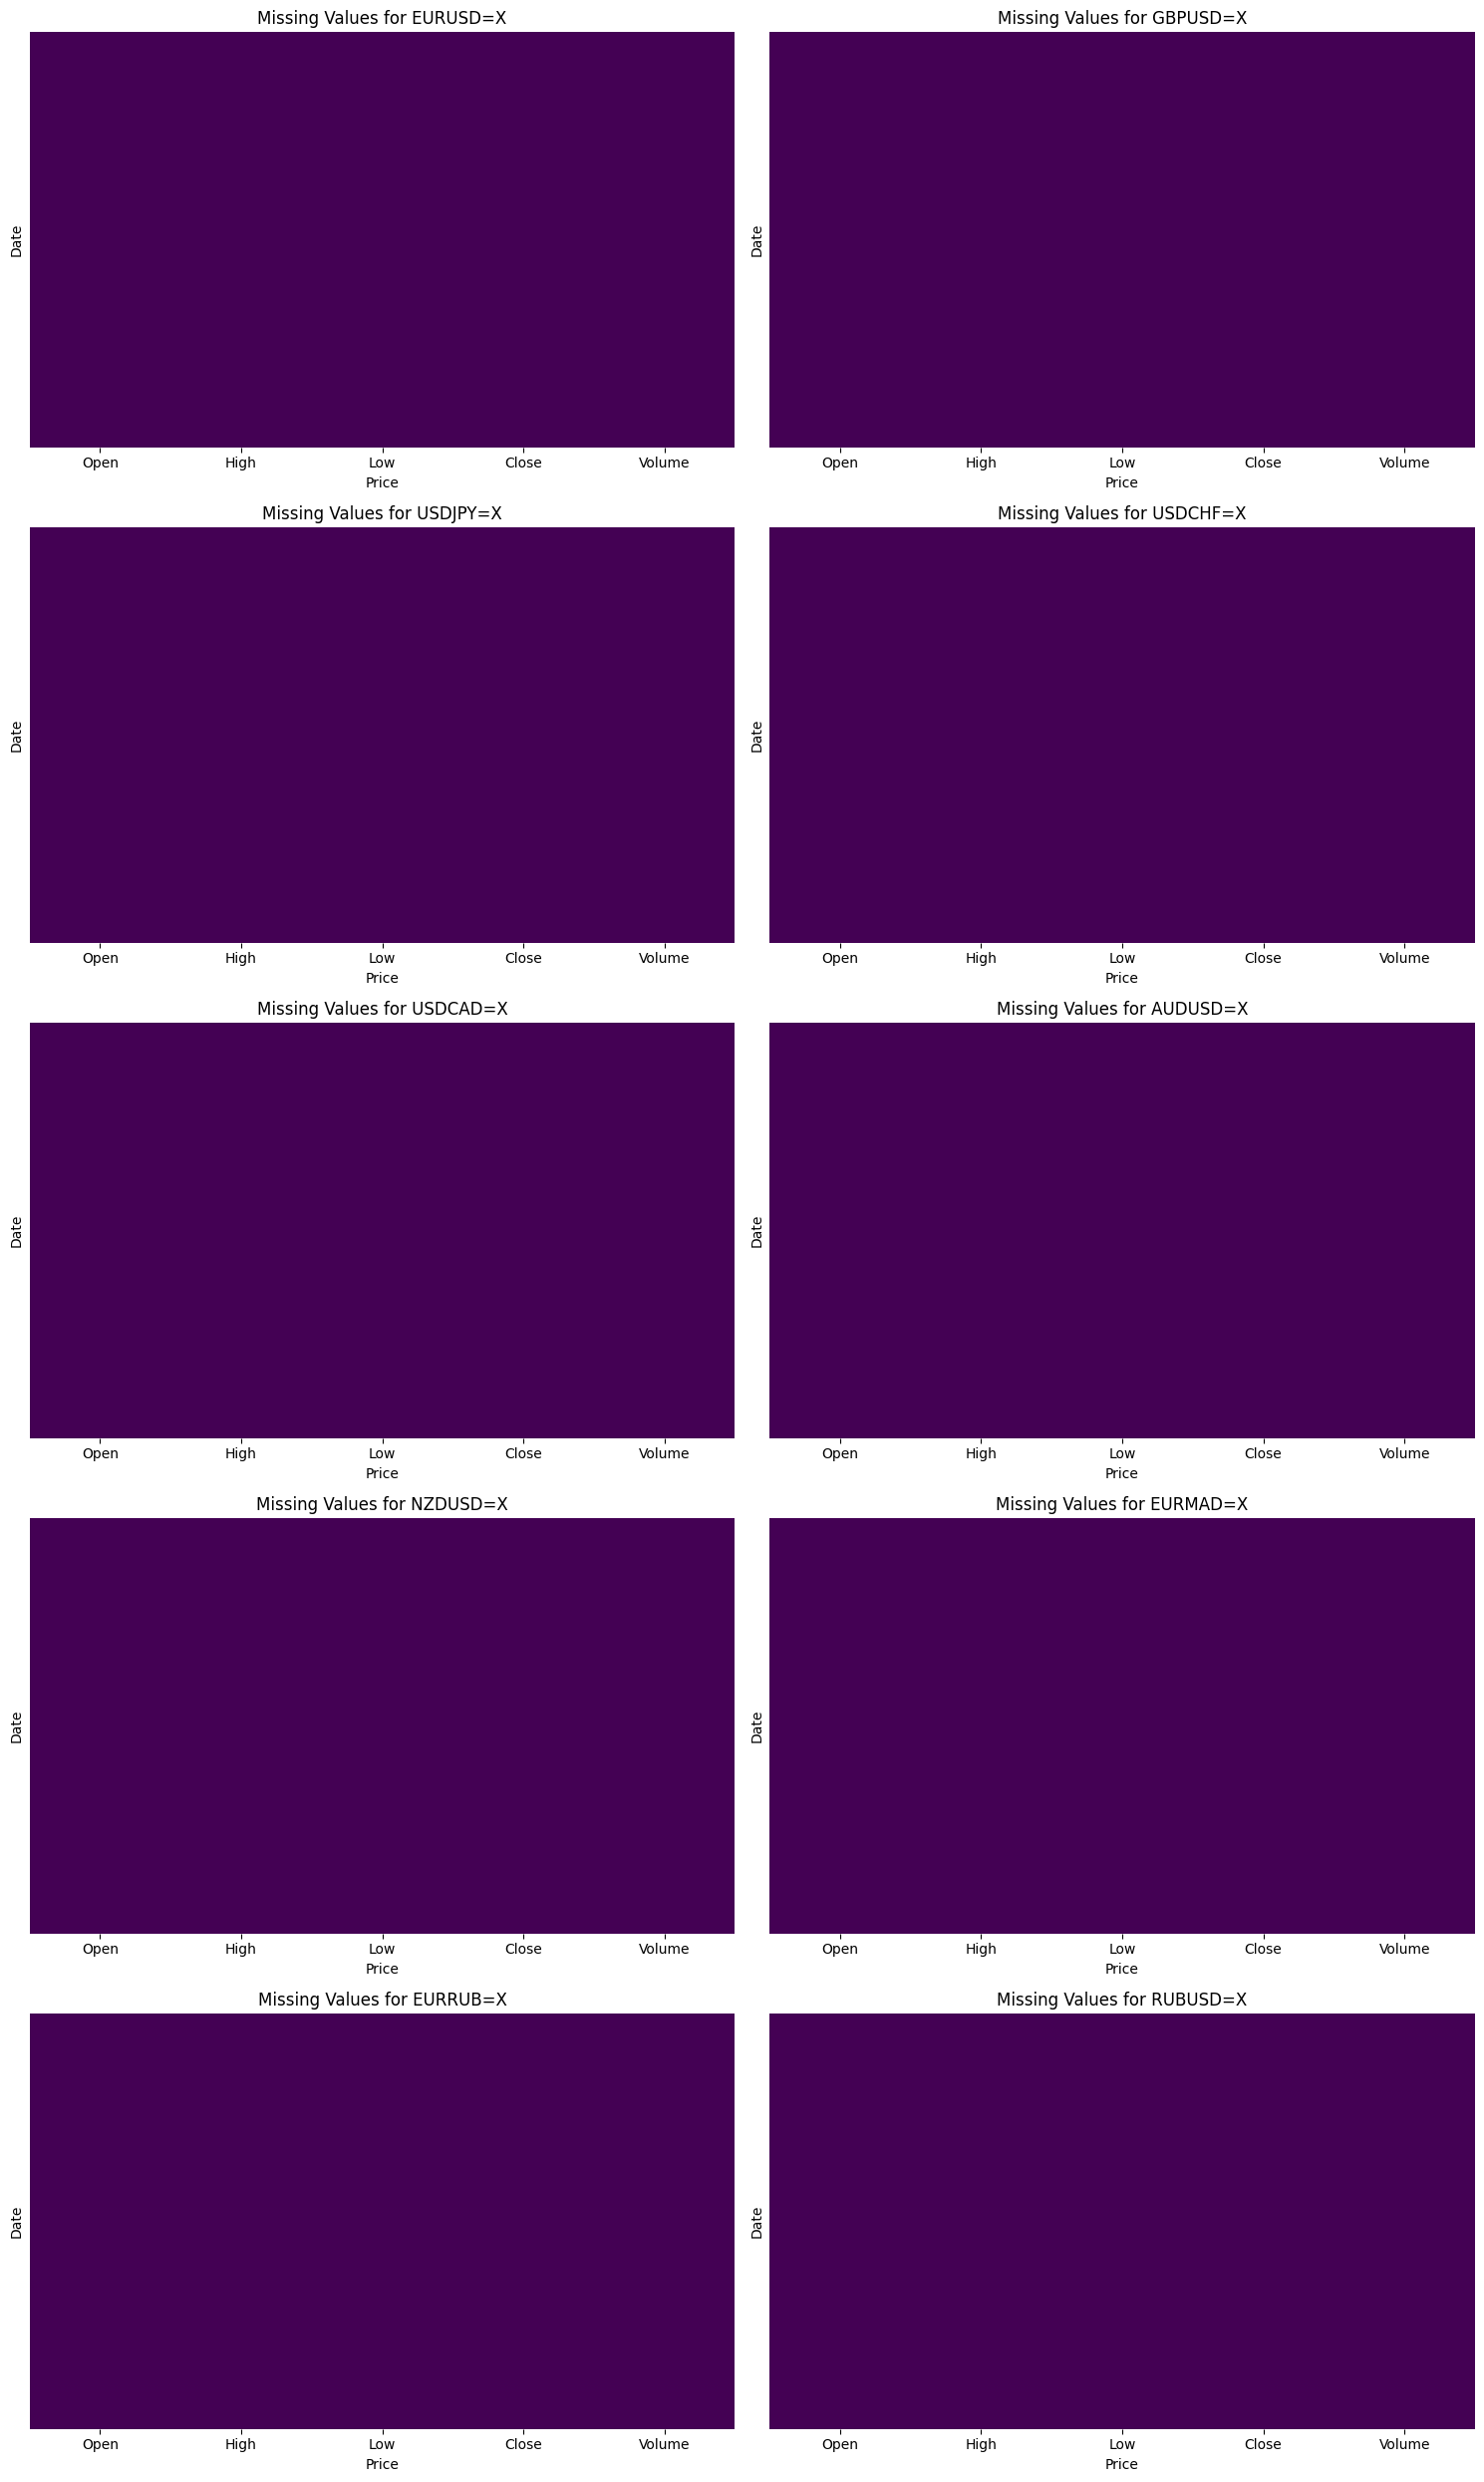

In [11]:
fig = plt.figure(figsize=(15, 25))
for i, ticker in enumerate(tickers):
  ax = fig.add_subplot(5, 2, i + 1)
  sns.heatmap(data=df[ticker].isnull(), yticklabels=False, cbar=False, cmap="viridis", ax=ax)
  ax.set_title(f'Missing Values for {ticker}')
plt.tight_layout()
plt.show()

In [12]:
# Handling missing values in times series can be done with 2 methods either Forward or Backward fill
df.fillna(method="ffill", inplace=True)
df.fillna(method="bfill", inplace=True)
df.isnull().sum()

/tmp/ipython-input-3846587118.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method="ffill", inplace=True)
/tmp/ipython-input-3846587118.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method="bfill", inplace=True)


Ticker    Price 
RUBUSD=X  Open      0
          High      0
          Low       0
          Close     0
          Volume    0
NZDUSD=X  Open      0
          High      0
          Low       0
          Close     0
          Volume    0
EURRUB=X  Open      0
          High      0
          Low       0
          Close     0
          Volume    0
USDCAD=X  Open      0
          High      0
          Low       0
          Close     0
          Volume    0
EURMAD=X  Open      0
          High      0
          Low       0
          Close     0
          Volume    0
AUDUSD=X  Open      0
          High      0
          Low       0
          Close     0
          Volume    0
USDJPY=X  Open      0
          High      0
          Low       0
          Close     0
          Volume    0
EURUSD=X  Open      0
          High      0
          Low       0
          Close     0
          Volume    0
GBPUSD=X  Open      0
          High      0
          Low       0
          Close     0
          Volume    0
USDCHF=X  Open      0
          High      0
          Low       0
          Close     0
          Volume    0
dtype: int64

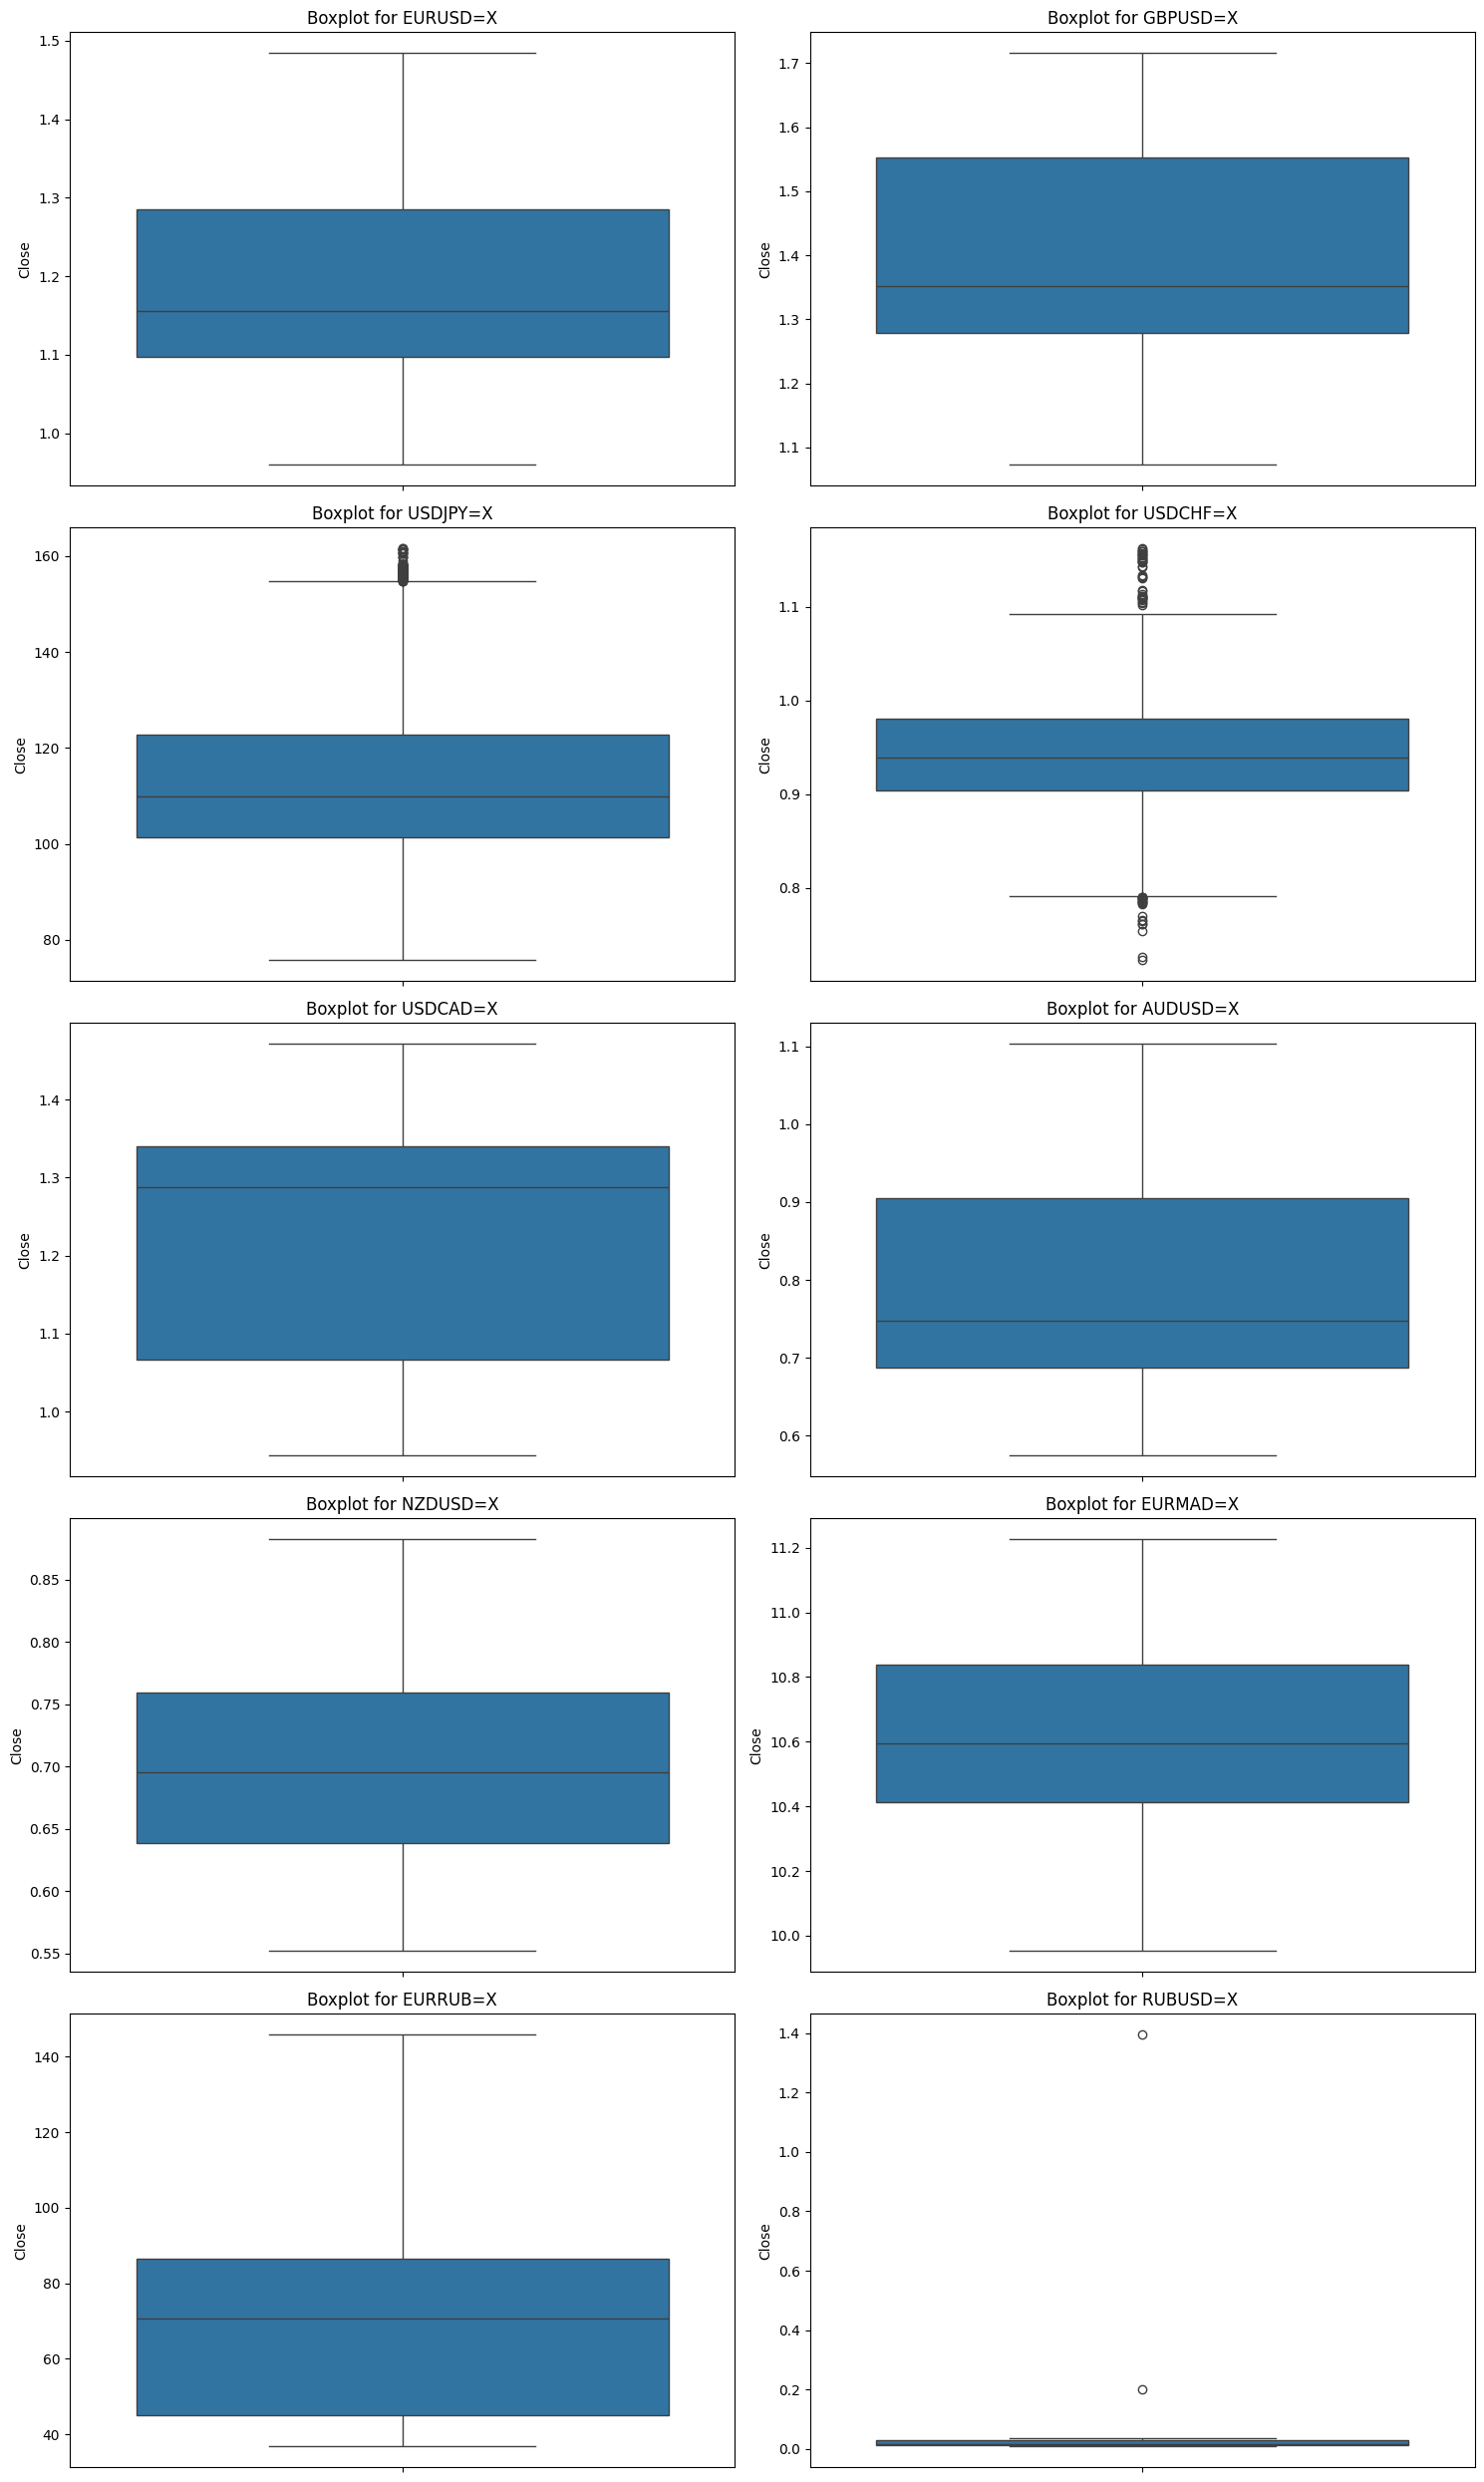

In [13]:
fig = plt.figure(figsize=(15, 25))
for i, ticker in enumerate(tickers):
  ax = fig.add_subplot(5, 2, i + 1)
  sns.boxplot(y=df[ticker]["Close"], ax = ax)
  ax.set_title(f'Boxplot for {ticker}')
plt.tight_layout()
plt.show()

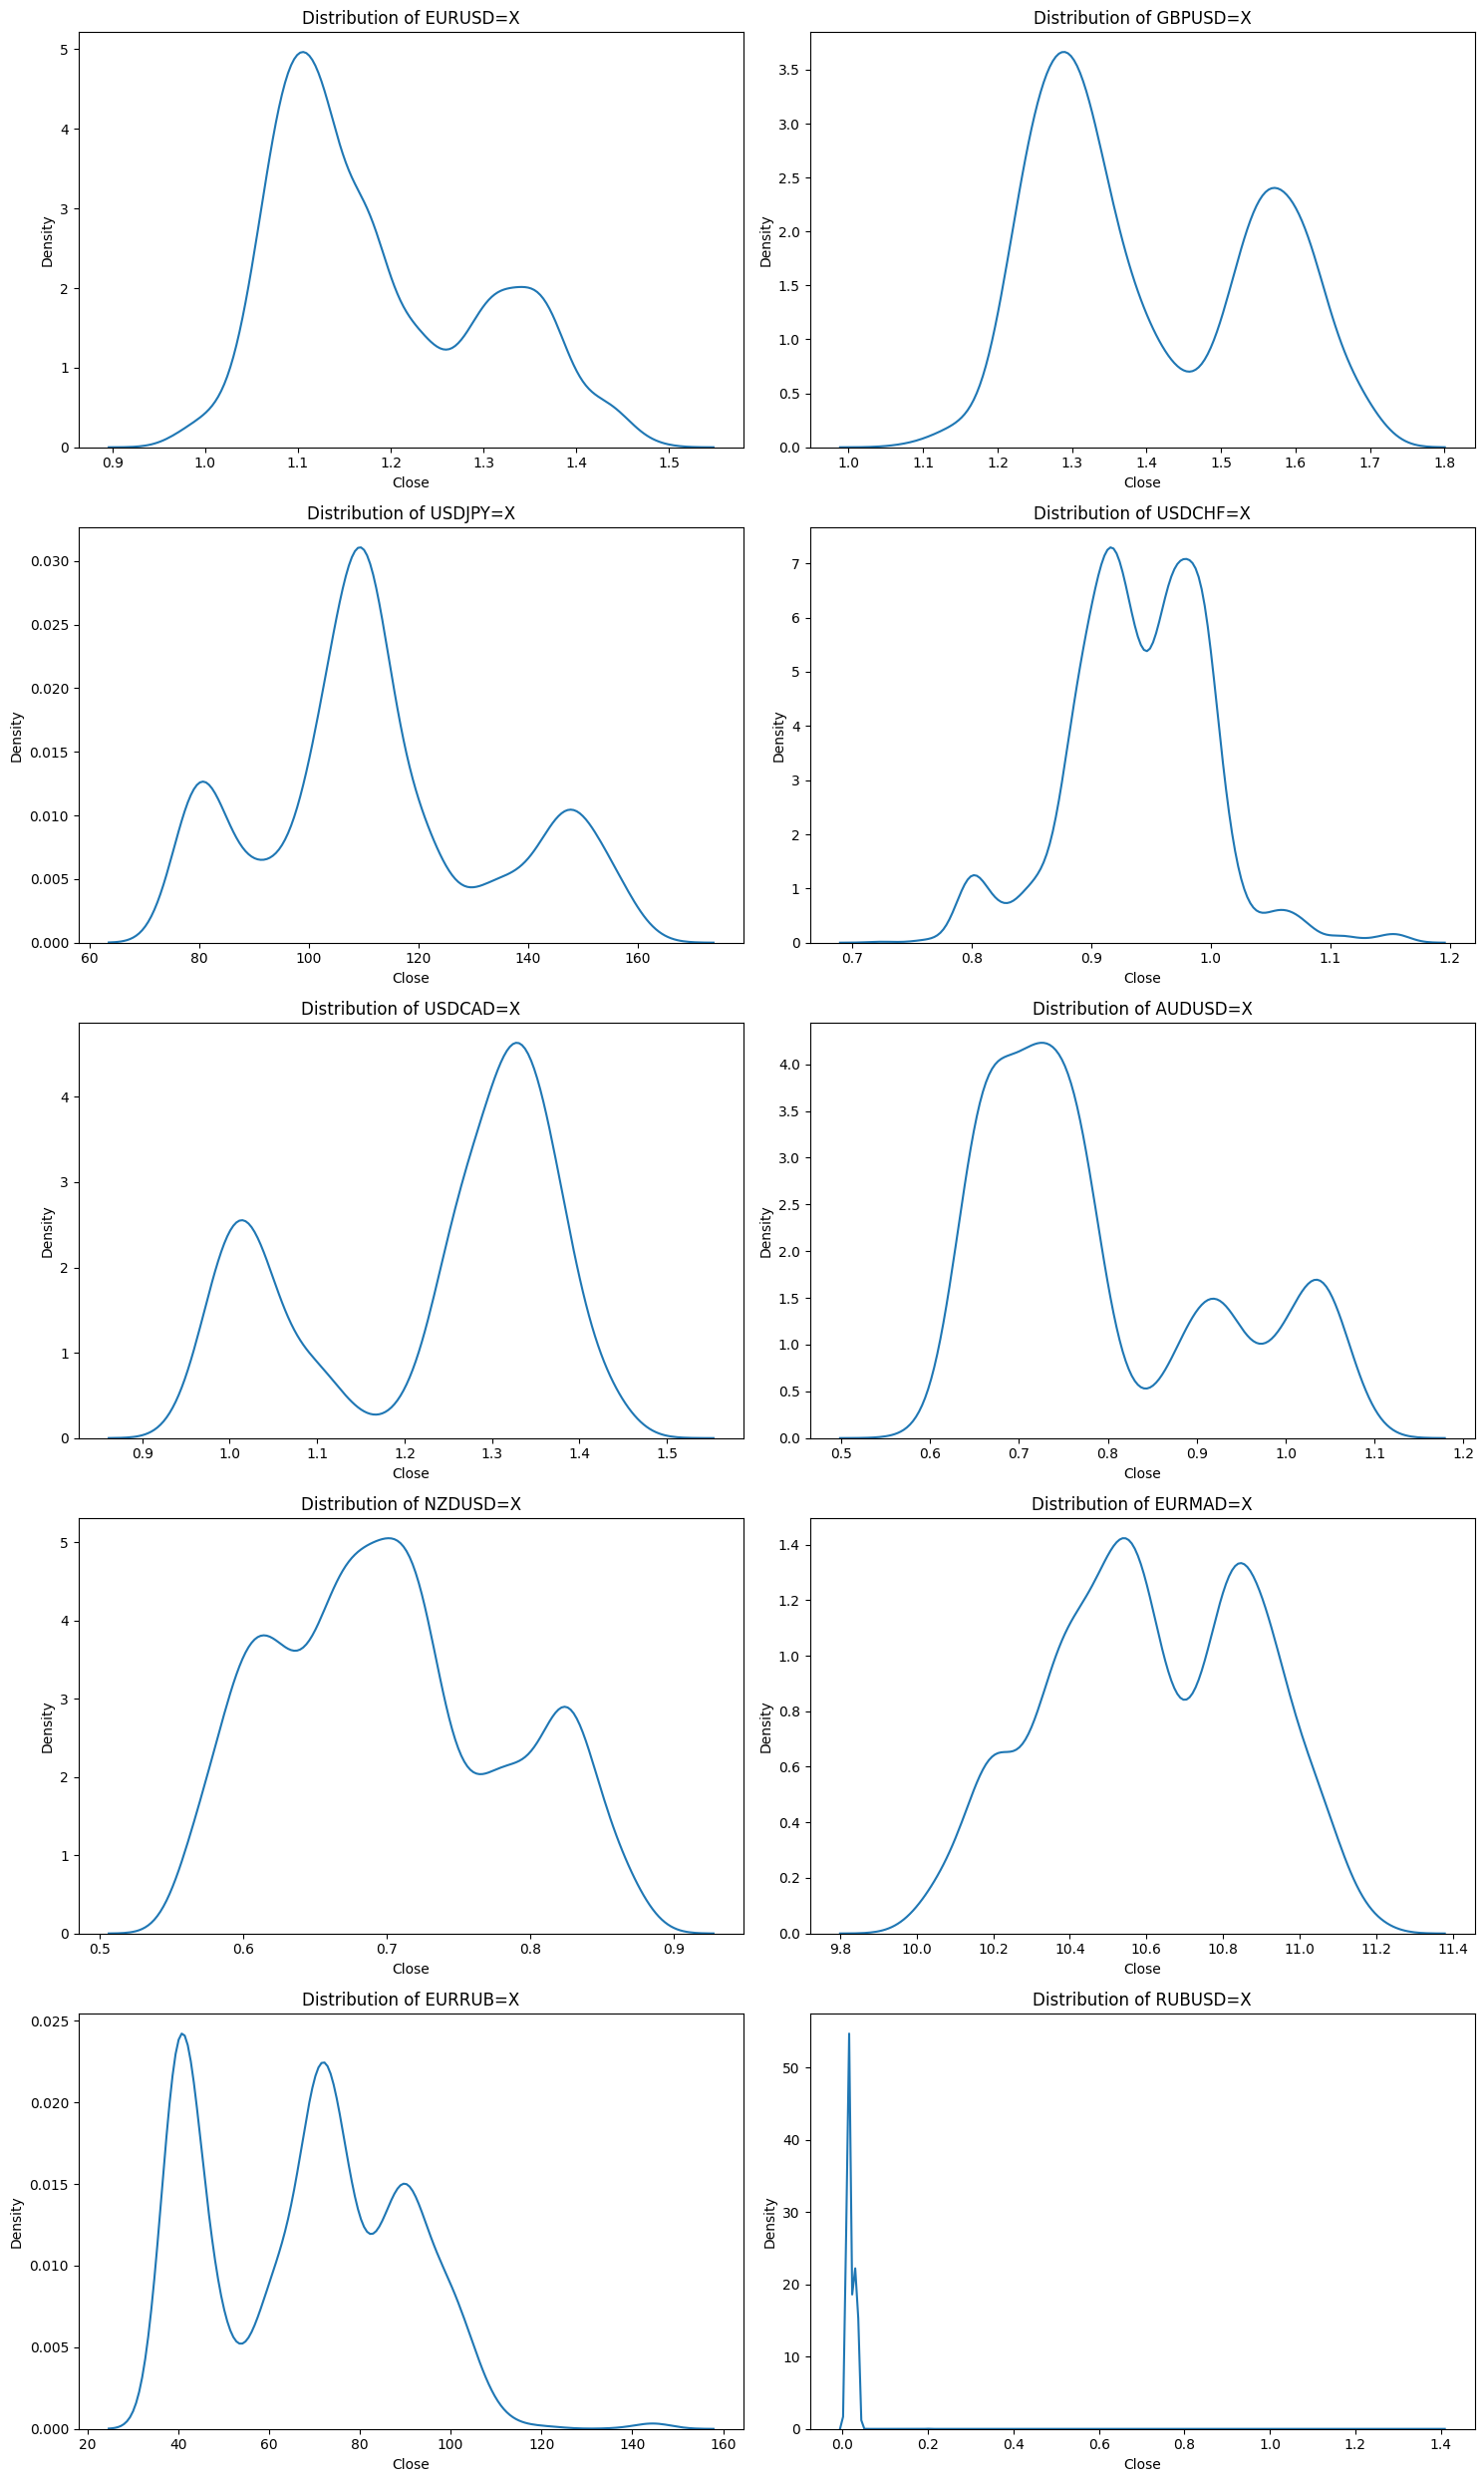

In [14]:
fig = plt.figure(figsize=(15, 25))
for i, ticker in enumerate(tickers):
  ax = fig.add_subplot(5, 2, i+1)
  sns.kdeplot(df[ticker]['Close'], ax=ax)
  ax.set_title(f'Distribution of {ticker}')
  ax.set_xlabel('Close')
  ax.set_ylabel('Density')
  plt.tight_layout()
plt.show()

In [15]:
df_zscore = df.apply(zscore)
columns_to_drop = [(ticker, 'Volume') for ticker in tickers]
print(columns_to_drop)
df_zscore= df_zscore.drop(columns= columns_to_drop)
display(df_zscore.head())

[('EURUSD=X', 'Volume'), ('GBPUSD=X', 'Volume'), ('USDJPY=X', 'Volume'), ('USDCHF=X', 'Volume'), ('USDCAD=X', 'Volume'), ('AUDUSD=X', 'Volume'), ('NZDUSD=X', 'Volume'), ('EURMAD=X', 'Volume'), ('EURRUB=X', 'Volume'), ('RUBUSD=X', 'Volume')]


Ticker      RUBUSD=X                                NZDUSD=X            \
Price           Open      High       Low     Close      Open      High   
Date                                                                     
2010-01-01  1.590865  1.612119  1.608069  0.575347  0.302575  0.254210   
2010-01-04  1.586189  1.669757  1.606312  0.560164  0.268375  0.363196   
2010-01-05  1.638509  1.624094  1.648618  0.575347  0.407416  0.410628   
2010-01-06  1.627590  1.710353  1.641217  0.575347  0.395947  0.408614   
2010-01-07  1.790773  1.775171  1.648618  0.575347  0.451534  0.454489   

Ticker                          EURRUB=X            ...  EURUSD=X            \
Price            Low     Close      Open      High  ...       Low     Close   
Date                                                ...                       
2010-01-01  0.319443  0.279280 -1.196057 -1.182859  ...  2.241133  2.251261   
2010-01-04  0.263110  0.401078 -1.196057 -1.182859  ...  2.182975  2.281613   
2010-01-05  0.417377  0.395684 -1.198289 -1.205384  ...  2.263400  2.229880   
2010-01-06  0.399231  0.448536 -1.251449 -1.216243  ...  2.209062  2.263829   
2010-01-07  0.406615  0.382230 -1.279894 -1.220940  ...  2.218759  2.187146   

Ticker      GBPUSD=X                                USDCHF=X            \
Price           Open      High       Low     Close      Open      High   
Date                                                                     
2010-01-01  1.436327  1.403086  1.433772  1.403341  1.610541  1.613090   
2010-01-04  1.406117  1.441420  1.389445  1.390400  1.641214  1.670778   
2010-01-05  1.393695  1.385511  1.325769  1.307725  1.520232  1.574065   
2010-01-06  1.309600  1.323228  1.308177  1.329959  1.598613  1.607999   
2010-01-07  1.328730  1.320106  1.279266  1.269505  1.496376  1.589336   

Ticker                          
Price            Low     Close  
Date                            
2010-01-01  1.666623  1.605377  
2010-01-04  1.543711  1.523598  
2010-01-05  1.516397  1.601969  
2010-01-06  1.514690  1.498044  
2010-01-07  1.501033  1.600265  

[5 rows x 40 columns]

In [16]:
outliers_count = (np.abs(df_zscore) > 3).sum()
print(f"Number of outliers in each column:\n{outliers_count}")

Number of outliers in each column:
Ticker    Price
RUBUSD=X  Open      0
          High      0
          Low       0
          Close     2
NZDUSD=X  Open      0
          High      3
          Low       0
          Close     0
EURRUB=X  Open     13
          High     15
          Low       6
          Close    15
USDCAD=X  Open      0
          High      0
          Low       0
          Close     0
EURMAD=X  Open      0
          High      0
          Low       0
          Close     0
AUDUSD=X  Open      0
          High      0
          Low       0
          Close     0
USDJPY=X  Open      0
          High      0
          Low       0
          Close     0
EURUSD=X  Open      0
          High      0
          Low       1
          Close     0
GBPUSD=X  Open      0
          High      0
          Low       1
          Close     0
USDCHF=X  Open     31
          High     29
          Low      31
          Close    31
dtype: int64


In [17]:
outliers_count = (np.abs(df_zscore) > 3).sum()
print(f"Number of outliers in each column:\n{outliers_count}")

Number of outliers in each column:
Ticker    Price
RUBUSD=X  Open      0
          High      0
          Low       0
          Close     2
NZDUSD=X  Open      0
          High      3
          Low       0
          Close     0
EURRUB=X  Open     13
          High     15
          Low       6
          Close    15
USDCAD=X  Open      0
          High      0
          Low       0
          Close     0
EURMAD=X  Open      0
          High      0
          Low       0
          Close     0
AUDUSD=X  Open      0
          High      0
          Low       0
          Close     0
USDJPY=X  Open      0
          High      0
          Low       0
          Close     0
EURUSD=X  Open      0
          High      0
          Low       1
          Close     0
GBPUSD=X  Open      0
          High      0
          Low       1
          Close     0
USDCHF=X  Open     31
          High     29
          Low      31
          Close    31
dtype: int64


In [18]:
df.loc[(np.abs(df_zscore['USDCHF=X']) > 3).any(axis=1), 'USDCHF=X']

Price,Open,High,Low,Close,Volume
Date,,,,,
2010-05-05,1.10440,1.11969,1.10224,1.11780,0.0
2010-05-06,1.11780,1.12439,1.10200,1.11370,0.0
2010-05-13,1.11045,1.11915,1.10780,1.11720,0.0
2010-05-14,1.11700,1.13350,1.11500,1.13320,0.0
2010-05-17,1.13210,1.14420,1.12960,1.13169,0.0
2010-05-18,1.13190,1.15130,1.12680,1.14980,0.0
2010-05-19,1.14920,1.15820,1.14341,1.15232,0.0
2010-05-20,1.15270,1.15696,1.14520,1.15000,0.0
2010-05-21,1.14950,1.15789,1.14510,1.14790,0.0


Reasons behind these outlier dates:
1. August 2011: The Swiss Franc (CHF) experienced a period of significant appreciation during this time, driven by its safe-haven status amidst the Eurozone debt crisis. The values dipping from ~1.1x to ~0.7x are indeed a stark deviation.

2. January 15, 2015: This date is famously known as 'Swiss National Bank (SNB) Black Thursday' or 'Francogeddon'. On this day, the SNB unexpectedly removed its cap on the Swiss franc against the euro, causing massive and sudden movements in the CHF, including against the USD. A 'Low' value of 0.73271 for USDCHF=X on this date (while other prices are around 1.01x) represents an unprecedented and truly extreme event in forex markets. It's a classic example of a financial 'black swan' event.



In [19]:
df = df.drop(columns=columns_to_drop)
df.head(5)

Ticker      RUBUSD=X                                NZDUSD=X            \
Price           Open      High       Low     Close      Open      High   
Date                                                                     
2010-01-01  0.033031  0.033339  0.032999  0.033339  0.726322  0.726322   
2010-01-04  0.032991  0.033823  0.032985  0.032988  0.723589  0.735186   
2010-01-05  0.033430  0.033439  0.033339  0.033339  0.734700  0.739044   
2010-01-06  0.033339  0.034164  0.033277  0.033339  0.733783  0.738880   
2010-01-07  0.034708  0.034708  0.033339  0.033339  0.738225  0.742611   

Ticker                           EURRUB=X             ...  EURUSD=X            \
Price            Low     Close       Open       High  ...       Low     Close   
Date                                                  ...                       
2010-01-01  0.724480  0.724480  43.319000  43.813099  ...  1.432706  1.438994   
2010-01-04  0.719994  0.734214  43.319000  43.813099  ...  1.426208  1.442398   
2010-01-05  0.732279  0.733783  43.271900  43.330200  ...  1.435194  1.436596   
2010-01-06  0.730834  0.738007  42.150200  43.097401  ...  1.429123  1.440403   
2010-01-07  0.731422  0.732708  41.549999  42.996700  ...  1.430206  1.431803   

Ticker      GBPUSD=X                               USDCHF=X                  \
Price           Open      High       Low     Close     Open    High     Low   
Date                                                                          
2010-01-01  1.618202  1.618202  1.613111  1.613294   1.0342  1.0381  1.0339   
2010-01-04  1.613710  1.623904  1.606503  1.611370   1.0360  1.0415  1.0267   
2010-01-05  1.611863  1.615587  1.597010  1.599079   1.0289  1.0358  1.0251   
2010-01-06  1.599360  1.606323  1.594388  1.602384   1.0335  1.0378  1.0250   
2010-01-07  1.602205  1.605858  1.590078  1.593397   1.0275  1.0367  1.0242   

Ticker              
Price        Close  
Date                
2010-01-01  1.0339  
2010-01-04  1.0291  
2010-01-05  1.0337  
2010-01-06  1.0276  
2010-01-07  1.0336  

[5 rows x 40 columns]

#### Granular Outlier Columns


In [20]:
price_types = ['Open', 'High', 'Low', 'Close']

for ticker in tickers:
    for price_type in price_types:
        column_name = (ticker, f'{price_type}_is_outlier')
        df[column_name] = (np.abs(df_zscore[(ticker, price_type)]) > 3).astype(int)

df.head()

Ticker      RUBUSD=X                                NZDUSD=X            \
Price           Open      High       Low     Close      Open      High   
Date                                                                     
2010-01-01  0.033031  0.033339  0.032999  0.033339  0.726322  0.726322   
2010-01-04  0.032991  0.033823  0.032985  0.032988  0.723589  0.735186   
2010-01-05  0.033430  0.033439  0.033339  0.033339  0.734700  0.739044   
2010-01-06  0.033339  0.034164  0.033277  0.033339  0.733783  0.738880   
2010-01-07  0.034708  0.034708  0.033339  0.033339  0.738225  0.742611   

Ticker                           EURRUB=X             ...       EURMAD=X  \
Price            Low     Close       Open       High  ... Low_is_outlier   
Date                                                  ...                  
2010-01-01  0.724480  0.724480  43.319000  43.813099  ...              0   
2010-01-04  0.719994  0.734214  43.319000  43.813099  ...              0   
2010-01-05  0.732279  0.733783  43.271900  43.330200  ...              0   
2010-01-06  0.730834  0.738007  42.150200  43.097401  ...              0   
2010-01-07  0.731422  0.732708  41.549999  42.996700  ...              0   

Ticker                             EURRUB=X                                 \
Price      Close_is_outlier Open_is_outlier High_is_outlier Low_is_outlier   
Date                                                                         
2010-01-01                0               0               0              0   
2010-01-04                0               0               0              0   
2010-01-05                0               0               0              0   
2010-01-06                0               0               0              0   
2010-01-07                0               0               0              0   

Ticker                             RUBUSD=X                                 \
Price      Close_is_outlier Open_is_outlier High_is_outlier Low_is_outlier   
Date                                                                         
2010-01-01                0               0               0              0   
2010-01-04                0               0               0              0   
2010-01-05                0               0               0              0   
2010-01-06                0               0               0              0   
2010-01-07                0               0               0              0   

Ticker                       
Price      Close_is_outlier  
Date                         
2010-01-01                0  
2010-01-04                0  
2010-01-05                0  
2010-01-06                0  
2010-01-07                0  

[5 rows x 80 columns]

In [21]:
price_types = ['Open', 'High', 'Low', 'Close']

for ticker in tickers:
    for price_type in price_types:
        column_name = (ticker, f'{price_type}_is_outlier')
        outlier_count = df[column_name].sum()
        print(f"Ticker: {ticker}, Price Type: {price_type}, Outlier Count: {outlier_count}")

Ticker: EURUSD=X, Price Type: Open, Outlier Count: 0
Ticker: EURUSD=X, Price Type: High, Outlier Count: 0
Ticker: EURUSD=X, Price Type: Low, Outlier Count: 1
Ticker: EURUSD=X, Price Type: Close, Outlier Count: 0
Ticker: GBPUSD=X, Price Type: Open, Outlier Count: 0
Ticker: GBPUSD=X, Price Type: High, Outlier Count: 0
Ticker: GBPUSD=X, Price Type: Low, Outlier Count: 1
Ticker: GBPUSD=X, Price Type: Close, Outlier Count: 0
Ticker: USDJPY=X, Price Type: Open, Outlier Count: 0
Ticker: USDJPY=X, Price Type: High, Outlier Count: 0
Ticker: USDJPY=X, Price Type: Low, Outlier Count: 0
Ticker: USDJPY=X, Price Type: Close, Outlier Count: 0
Ticker: USDCHF=X, Price Type: Open, Outlier Count: 31
Ticker: USDCHF=X, Price Type: High, Outlier Count: 29
Ticker: USDCHF=X, Price Type: Low, Outlier Count: 31
Ticker: USDCHF=X, Price Type: Close, Outlier Count: 31
Ticker: USDCAD=X, Price Type: Open, Outlier Count: 0
Ticker: USDCAD=X, Price Type: High, Outlier Count: 0
Ticker: USDCAD=X, Price Type: Low, Outlier

In [22]:
df[("USDCHF=X", "High_is_outlier")]

,USDCHF=X
,High_is_outlier
Date,
2010-01-01,0
2010-01-04,0
2010-01-05,0
2010-01-06,0
2010-01-07,0
...,...
2025-12-17,0
2025-12-18,0


## Feature engineering

In [ ]:
new_features_dfs = []
ma_windows = [5, 10, 20]
ema_windows = [5, 12, 26]
volatility_windows = [10, 20]
momentum_window = 5
price_types = ['Open', 'High', 'Low', 'Close']

for ticker in tickers:
    ticker_features = {}
    ticker_panel = df[ticker]
    close = ticker_panel['Close']
    high = ticker_panel['High']
    low = ticker_panel['Low']

    for price_type in price_types:
        price = ticker_panel[price_type]
        log_series = np.log(price)
        ticker_features[(ticker, f"{price_type}_log")] = log_series
        ticker_features[(ticker, f"{price_type}_diff")] = price.diff()
        ticker_features[(ticker, f"{price_type}_log_return")] = log_series.diff()

    log_return_close = ticker_features[(ticker, 'Close_log_return')]

    ticker_features[(ticker, f'Close_momentum_{momentum_window}')] = close - close.shift(momentum_window)

    for window in ma_windows:
        ticker_features[(ticker, f'Close_ma_{window}')] = close.rolling(window).mean()

    for window in ema_windows:
        ticker_features[(ticker, f'Close_ema_{window}')] = close.ewm(span=window, adjust=False).mean()

    for window in volatility_windows:
        ticker_features[(ticker, f'Close_log_return_vol_{window}')] = log_return_close.rolling(window).std()

    ticker_features[(ticker, 'High_low_range')] = high - low
    ticker_features[(ticker, 'High_low_range_pct')] = (high - low) / low.replace(0, np.nan)
    ticker_features[(ticker, 'Close_direction')] = np.sign(log_return_close.fillna(0))

    new_features_dfs.append(pd.DataFrame(ticker_features))

df = pd.concat([df.copy()] + new_features_dfs, axis=1)

In [24]:
df.fillna(method='ffill', inplace=True)
df.fillna(method='bfill', inplace=True)
df.isna().sum()

/tmp/ipython-input-2590723928.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)
/tmp/ipython-input-2590723928.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='bfill', inplace=True)


RUBUSD=X  Open                0
          High                0
          Low                 0
          Close               0
NZDUSD=X  Open                0
                             ..
RUBUSD=X  Low_diff            0
          Low_log_return      0
          Close_log           0
          Close_diff          0
          Close_log_return    0
Length: 200, dtype: int64

In [ ]:
stationarity_records = []

for ticker in tickers:
    series = df[(ticker, 'Close_log_return')].dropna()
    if len(series) < 50:
        continue
    adf_stat, p_value, usedlag, nobs, crit_vals, icbest = adfuller(series)
    stationarity_records.append({
        'Ticker': ticker,
        'ADF Statistic': adf_stat,
        'p-value': p_value,
        'Used Lag': usedlag,
        'nobs': nobs,
        '1% Crit': crit_vals['1%'],
        '5% Crit': crit_vals['5%'],
        '10% Crit': crit_vals['10%'],
        'Stationary': p_value < 0.05
    })

stationarity_df = pd.DataFrame(stationarity_records).set_index('Ticker')
stationarity_df['Stationary'] = stationarity_df['Stationary'].map({True: 'Yes', False: 'No'})

print("Stationarity check for log-return target (ADF test)")
display(stationarity_df)


In [25]:
df["EURUSD=X"].columns

Index(['Open', 'High', 'Low', 'Close', 'Open_is_outlier', 'High_is_outlier',
       'Low_is_outlier', 'Close_is_outlier', 'Open_log', 'Open_diff',
       'Open_log_return', 'High_log', 'High_diff', 'High_log_return',
       'Low_log', 'Low_diff', 'Low_log_return', 'Close_log', 'Close_diff',
       'Close_log_return'],
      dtype='object')

In [26]:
df.isin(values=['-inf','inf']).value_counts()

,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,count
"(RUBUSD=X, Open)","(RUBUSD=X, High)","(RUBUSD=X, Low)","(RUBUSD=X, Close)","(NZDUSD=X, Open)","(NZDUSD=X, High)","(NZDUSD=X, Low)","(NZDUSD=X, Close)","(EURRUB=X, Open)","(EURRUB=X, High)","(EURRUB=X, Low)","(EURRUB=X, Close)","(USDCAD=X, Open)","(USDCAD=X, High)","(USDCAD=X, Low)","(USDCAD=X, Close)","(EURMAD=X, Open)","(EURMAD=X, High)","(EURMAD=X, Low)","(EURMAD=X, Close)","(AUDUSD=X, Open)","(AUDUSD=X, High)","(AUDUSD=X, Low)","(AUDUSD=X, Close)","(USDJPY=X, Open)","(USDJPY=X, High)","(USDJPY=X, Low)","(USDJPY=X, Close)","(EURUSD=X, Open)","(EURUSD=X, High)","(EURUSD=X, Low)","(EURUSD=X, Close)","(GBPUSD=X, Open)","(GBPUSD=X, High)","(GBPUSD=X, Low)","(GBPUSD=X, Close)","(USDCHF=X, Open)","(USDCHF=X, High)","(USDCHF=X, Low)","(USDCHF=X, Close)","(EURUSD=X, Open_is_outlier)","(EURUSD=X, High_is_outlier)","(EURUSD=X, Low_is_outlier)","(EURUSD=X, Close_is_outlier)","(GBPUSD=X, Open_is_outlier)","(GBPUSD=X, High_is_outlier)","(GBPUSD=X, Low_is_outlier)","(GBPUSD=X, Close_is_outlier)","(USDJPY=X, Open_is_outlier)","(USDJPY=X, High_is_outlier)","(USDJPY=X, Low_is_outlier)","(USDJPY=X, Close_is_outlier)","(USDCHF=X, Open_is_outlier)","(USDCHF=X, High_is_outlier)","(USDCHF=X, Low_is_outlier)","(USDCHF=X, Close_is_outlier)","(USDCAD=X, Open_is_outlier)","(USDCAD=X, High_is_outlier)","(USDCAD=X, Low_is_outlier)","(USDCAD=X, Close_is_outlier)","(AUDUSD=X, Open_is_outlier)","(AUDUSD=X, High_is_outlier)","(AUDUSD=X, Low_is_outlier)","(AUDUSD=X, Close_is_outlier)","(NZDUSD=X, Open_is_outlier)","(NZDUSD=X, High_is_outlier)","(NZDUSD=X, Low_is_outlier)","(NZDUSD=X, Close_is_outlier)","(EURMAD=X, Open_is_outlier)","(EURMAD=X, High_is_outlier)","(EURMAD=X, Low_is_outlier)","(EURMAD=X, Close_is_outlier)","(EURRUB=X, Open_is_outlier)","(EURRUB=X, High_is_outlier)","(EURRUB=X, Low_is_outlier)","(EURRUB=X, Close_is_outlier)","(RUBUSD=X, Open_is_outlier)","(RUBUSD=X, High_is_outlier)","(RUBUSD=X, Low_is_outlier)","(RUBUSD=X, Close_is_outlier)","(EURUSD=X, Open_log)","(EURUSD=X, Open_diff)","(EURUSD=X, Open_log_return)","(EURUSD=X, High_log)","(EURUSD=X, High_diff)","(EURUSD=X, High_log_return)","(EURUSD=X, Low_log)","(EURUSD=X, Low_diff)","(EURUSD=X, Low_log_return)","(EURUSD=X, Close_log)","(EURUSD=X, Close_diff)","(EURUSD=X, Close_log_return)","(GBPUSD=X, Open_log)","(GBPUSD=X, Open_diff)","(GBPUSD=X, Open_log_return)","(GBPUSD=X, High_log)","(GBPUSD=X, High_diff)","(GBPUSD=X, High_log_return)","(GBPUSD=X, Low_log)","(GBPUSD=X, Low_diff)","(GBPUSD=X, Low_log_return)","(GBPUSD=X, Close_log)","(GBPUSD=X, Close_diff)","(GBPUSD=X, Close_log_return)","(USDJPY=X, Open_log)","(USDJPY=X, Open_diff)","(USDJPY=X, Open_log_return)","(USDJPY=X, High_log)","(USDJPY=X, High_diff)","(USDJPY=X, High_log_return)","(USDJPY=X, Low_log)","(USDJPY=X, Low_diff)","(USDJPY=X, Low_log_return)","(USDJPY=X, Close_log)","(USDJPY=X, Close_diff)","(USDJPY=X, Close_log_return)","(USDCHF=X, Open_log)","(USDCHF=X, Open_diff)","(USDCHF=X, Open_log_return)","(USDCHF=X, High_log)","(USDCHF=X, High_diff)","(USDCHF=X, High_log_return)","(USDCHF=X, Low_log)","(USDCHF=X, Low_diff)","(USDCHF=X, Low_log_return)","(USDCHF=X, Close_log)","(USDCHF=X, Close_diff)","(USDCHF=X, Close_log_return)","(USDCAD=X, Open_log)","(USDCAD=X, Open_diff)","(USDCAD=X, Open_log_return)","(USDCAD=X, High_log)","(USDCAD=X, High_diff)","(USDCAD=X, High_log_return)","(USDCAD=X, Low_log)","(USDCAD=X, Low_diff)","(USDCAD=X, Low_log_return)","(USDCAD=X, Close_log)","(USDCAD=X, Close_diff)","(USDCAD=X, Close_log_return)","(AUDUSD=X, Open_log)","(AUDUSD=X, Open_diff)","(AUDUSD=X, Open_log_return)","(AUDUSD=X, High_log)","(AUDUSD=X, High_diff)","(AUDUSD=X, High_log_return)","(AUDUSD=X, Low_log)","(AUDUSD=X, Low_diff)","(AUDUSD=X, Low_log_return)","(AUDUSD=X, Close_log)","(AUDUSD=X, Close_diff)","(AUDUSD=X, Close

In [27]:
df.dtypes

RUBUSD=X  Open                float64
          High                float64
          Low                 float64
          Close               float64
NZDUSD=X  Open                float64
                               ...   
RUBUSD=X  Low_diff            float64
          Low_log_return      float64
          Close_log           float64
          Close_diff          float64
          Close_log_return    float64
Length: 200, dtype: object

## Modeling

In [ ]:
import lightgbm as lgb
from sklearn.preprocessing import StandardScaler

lookback = 200
forecast_horizon = 1
walk_step = 25
transaction_cost = 0.0001
feature_columns = [
    'Open',
    'High',
    'Low',
    'Close',
    'Close_log',
    'Close_log_return',
    'Close_momentum_5',
    'Close_ma_5',
    'Close_ma_10',
    'Close_ma_20',
    'Close_ema_5',
    'Close_ema_12',
    'Close_ema_26',
    'Close_log_return_vol_10',
    'Close_log_return_vol_20',
    'High_low_range',
    'High_low_range_pct',
    'Close_direction'
]

results = []
pnl_records = []


def create_walk_forward_splits(n_samples, lookback, step):
    splits = []
    start = lookback
    while start + step <= n_samples:
        splits.append((slice(0, start), slice(start, start + step)))
        start += step
    return splits


for ticker in tickers:
    ticker_df = df[ticker].copy()
    ticker_df = ticker_df[feature_columns + ['Close_log_return']].copy()
    ticker_df['target'] = ticker_df['Close_log_return'].shift(-forecast_horizon)
    ticker_df = ticker_df.dropna()

    if len(ticker_df) < lookback + walk_step:
        print(f"Skipping {ticker} because there is not enough history for a {lookback}-day lookback.")
        continue

    splits = create_walk_forward_splits(len(ticker_df), lookback, walk_step)
    if not splits:
        print(f"Walk-forward could not be created for {ticker}.")
        continue

    X = ticker_df[feature_columns]
    y = ticker_df['target'].values
    date_index = ticker_df.index

    fold_records = []
    fold_pnl_frames = []

    for fold_idx, (train_slice, test_slice) in enumerate(splits):
        X_train, X_test = X.iloc[train_slice], X.iloc[test_slice]
        y_train, y_test = y[train_slice], y[test_slice]
        dates_test = date_index[test_slice]

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        model = lgb.LGBMRegressor(
            n_estimators=300,
            learning_rate=0.01,
            num_leaves=32,
            colsample_bytree=0.8,
            subsample=0.8,
            random_state=42,
            n_jobs=-1
        )
        model.fit(X_train_scaled, y_train)

        preds = model.predict(X_test_scaled)
        positions = np.sign(preds)
        positions[np.abs(preds) < 1e-5] = 0
        prev_positions = np.concatenate([[0], positions[:-1]])
        costs = transaction_cost * np.abs(positions - prev_positions)
        net_returns = positions * y_test - costs

        cumulative = np.cumsum(net_returns)
        running_max = np.maximum.accumulate(cumulative)
        max_drawdown = np.max(running_max - cumulative) if len(cumulative) else 0
        sharpe = (
            np.mean(net_returns) / np.std(net_returns)
            * np.sqrt(252)
            if np.std(net_returns) > 0
            else np.nan
        )
        hit_rate = np.mean(np.sign(preds) == np.sign(y_test))
        ic = (
            np.corrcoef(preds, y_test)[0, 1]
            if np.std(preds) > 0 and np.std(y_test) > 0
            else np.nan
        )

        fold_records.append({
            'Ticker': ticker,
            'Fold': fold_idx,
            'Sharpe': sharpe,
            'Max Drawdown': max_drawdown,
            'Hit Rate': hit_rate,
            'IC': ic,
            'Net PnL': net_returns.sum()
        })

        fold_pnl_frames.append(
            pd.DataFrame({
                'Date': dates_test,
                'Ticker': ticker,
                'Fold': fold_idx,
                'Prediction': preds,
                'Actual': y_test,
                'Position': positions,
                'Net PnL': net_returns
            })
        )

    summary = pd.DataFrame(fold_records)
    results.append(summary)
    pnl_records.append(pd.concat(fold_pnl_frames, ignore_index=True))

if results:
    cross_ticker_summary = pd.concat(results)
    summary_df = cross_ticker_summary.groupby('Ticker').agg({
        'Sharpe': 'mean',
        'Max Drawdown': 'max',
        'Hit Rate': 'mean',
        'IC': 'mean',
        'Net PnL': 'sum'
    }).reset_index()
    summary_df.columns = ['Ticker', 'Sharpe', 'Max Drawdown', 'Hit Rate', 'Info Coefficient', 'Net PnL']

    print("Walk-forward LightGBM backtest summary")
    display(summary_df)

    pnl_timeline = pd.concat(pnl_records)
    pnl_timeline['Equity'] = np.cumsum(pnl_timeline['Net PnL'])

    fig, ax = plt.subplots(1, 2, figsize=(14, 4))
    for ticker, grp in pnl_timeline.groupby('Ticker'):
        ax[0].plot(grp['Date'], grp['Equity'], label=ticker)
    ax[0].set_title('Cumulative PnL (log-return space)')
    ax[0].set_ylabel('Log-return accumulation')
    ax[0].legend()

    sns.histplot(pnl_timeline['Net PnL'], bins=50, ax=ax[1])
    ax[1].set_title('Histogram of daily PnL (post cost)')
    ax[1].set_xlabel('Net PnL (log return)')
    fig.tight_layout()
    plt.show()
else:
    print('No tickers had enough history to run the walk-forward backtest.')

In [28]:
print(df.columns)

MultiIndex([('RUBUSD=X',             'Open'),
            ('RUBUSD=X',             'High'),
            ('RUBUSD=X',              'Low'),
            ('RUBUSD=X',            'Close'),
            ('NZDUSD=X',             'Open'),
            ('NZDUSD=X',             'High'),
            ('NZDUSD=X',              'Low'),
            ('NZDUSD=X',            'Close'),
            ('EURRUB=X',             'Open'),
            ('EURRUB=X',             'High'),
            ...
            ('RUBUSD=X',  'Open_log_return'),
            ('RUBUSD=X',         'High_log'),
            ('RUBUSD=X',        'High_diff'),
            ('RUBUSD=X',  'High_log_return'),
            ('RUBUSD=X',          'Low_log'),
            ('RUBUSD=X',         'Low_diff'),
            ('RUBUSD=X',   'Low_log_return'),
            ('RUBUSD=X',        'Close_log'),
            ('RUBUSD=X',       'Close_diff'),
            ('RUBUSD=X', 'Close_log_return')],
           length=200)


In [ ]:
columns_to_keep = []
price_types = ['Open', 'High', 'Low', 'Close']

for ticker in tickers:
    for price_type in price_types:
        columns_to_keep.append((ticker, price_type))
        columns_to_keep.append((ticker, f'{price_type}_log'))
        columns_to_keep.append((ticker, f'{price_type}_log_return'))

df_selected_features = df[columns_to_keep]

display(df_selected_features.head())
print(f"New DataFrame shape: {df_selected_features.shape}")

EURUSD=X                                                      \
                Open Open_is_outlier  Open_log Open_log_return      High   
Date                                                                       
2010-01-01  1.432706               0  0.359565       -0.001188  1.440196   
2010-01-04  1.431004               0  0.358376       -0.001188  1.445191   
2010-01-05  1.442710               0  0.366523        0.008147  1.448310   
2010-01-06  1.436596               0  0.362276       -0.004247  1.443460   
2010-01-07  1.440300               0  0.364851        0.002575  1.444481   

                                                                               \
           High_is_outlier  High_log High_log_return       Low Low_is_outlier   
Date                                                                            
2010-01-01               0  0.364779        0.003462  1.432706              0   
2010-01-04               0  0.368242        0.003462  1.426208              0   
2010-01-05               0  0.370397        0.002156  1.435194              0   
2010-01-06               0  0.367043       -0.003354  1.429123              0   
2010-01-07               0  0.367750        0.000708  1.430206              0   

            ...  RUBUSD=X                                                     \
            ...  High_log High_log_return       Low Low_is_outlier   Low_log   
Date        ...                                                                
2010-01-01  ... -3.401037        0.014412  0.032999              0 -3.411263   
2010-01-04  ... -3.386625        0.014412  0.032985              0 -3.411709   
2010-01-05  ... -3.398026       -0.011401  0.033339              0 -3.401037   
2010-01-06  ... -3.376597        0.021428  0.033277              0 -3.402896   
2010-01-07  ... -3.360792        0.015805  0.033339              0 -3.401037   

                                                                \
           Low_log_return     Close Close_is_outlier Close_log   
Date                                                             
2010-01-01      -0.000445  0.033339                0 -3.401037   
2010-01-04      -0.000445  0.032988                0 -3.411610   
2010-01-05       0.010671  0.033339                0 -3.401037   
2010-01-06      -0.001859  0.033339                0 -3.401037   
2010-01-07       0.001859  0.033339                0 -3.401037   

                             
           Close_log_return  
Date                         
2010-01-01        -0.010572  
2010-01-04        -0.010572  
2010-01-05         0.010572  
2010-01-06         0.000000  
2010-01-07         0.000000  

[5 rows x 160 columns]

New DataFrame shape: (4163, 160)


In [30]:
print(df_selected_features.isnull().sum().sum())
print(df_selected_features.isna().sum().sum())

0
0


In [31]:
inf_values = df_selected_features.isin([np.inf, -np.inf]).sum().sum()
print(f"Number of infinite values in df_selected_features: {inf_values}")

Number of infinite values in df_selected_features: 0


In [32]:
print(df_selected_features.dtypes)

EURUSD=X  Open                float64
          Open_is_outlier       int64
          Open_log            float64
          Open_log_return     float64
          High                float64
                               ...   
RUBUSD=X  Low_log_return      float64
          Close               float64
          Close_is_outlier      int64
          Close_log           float64
          Close_log_return    float64
Length: 160, dtype: object


In [33]:
date_diffs = df_selected_features.index.to_series().diff().dt.days
gaps = date_diffs[date_diffs > 1]
if not gaps.empty:
    print("Found gaps in the time series index:")
    print(gaps)
else:
    print("No gaps found in the time series index (all consecutive dates are 1 day apart).")

Found gaps in the time series index:
Date
2010-01-04    3.0
2010-01-11    3.0
2010-01-18    3.0
2010-01-25    3.0
2010-02-01    3.0
             ... 
2025-11-24    3.0
2025-12-01    3.0
2025-12-08    3.0
2025-12-15    3.0
2025-12-22    3.0
Name: Date, Length: 837, dtype: float64


## Feature Schemas

For each selected feature, conceptually define its name, data type, calculation logic, and raw data source. This establishes clear metadata for your features.


### Conceptual Feature Schemas

| Feature Name                     | Data Type | Calculation Logic                      | Raw Data Source                                   |
|:---------------------------------|:----------|:---------------------------------------|:--------------------------------------------------|
| `('EURUSD=X', 'Open')`           | `float64` | Original opening price                 | `yf.download` for `EURUSD=X` `Open` price         |
| `('EURUSD=X', 'Open_is_outlier')`| `int64`   | Binary flag (1 if Z-score > 3, else 0)| `yf.download` for `EURUSD=X` `Open` price, `zscore` |
| `('EURUSD=X', 'Open_log')`       | `float64` | Natural logarithm of `Open` price      | `yf.download` for `EURUSD=X` `Open` price         |
| `('EURUSD=X', 'Open_log_return')`| `float64` | Logarithmic return of `Open` price     | `yf.download` for `EURUSD=X` `Open` price         |
| `('USDCHF=X', 'Close')`          | `float64` | Original closing price                 | `yf.download` for `USDCHF=X` `Close` price        |
| `('USDCHF=X', 'Close_is_outlier')`| `int64`   | Binary flag (1 if Z-score > 3, else 0)| `yf.download` for `USDCHF=X` `Close` price, `zscore`|
| `('USDCHF=X', 'Close_log')`      | `float64` | Natural logarithm of `Close` price     | `yf.download` for `USDCHF=X` `Close` price        |
| `('USDCHF=X', 'Close_log_return')`| `float64` | Logarithmic return of `Close` price    | `yf.download` for `USDCHF=X` `Close` price        |

In [ ]:
for ticker in tickers:
  X = df_selected_features.drop(columns=(ticker, 'Close'))
  y = df_selected_features[(ticker, 'Close_log_return')]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (4163, 159)
y shape: (4163,)


In [35]:
def check_feature_existence(X):
  for ticker in tickers:
    if 'Close' in X.columns:
      return True
    else:
      return False

check_feature_existence(X)

False

## Model training

In [36]:
# Sequence & Window creation
def create_sequences(features, targets, window_size, forecast_horizon):
  X_seq, y_seq = [], []
  for j in range(len(features) - window_size - forecast_horizon + 1):
      X_seq.append(features[j : (j + window_size)])
      y_seq.append(targets[j + window_size : j + window_size + forecast_horizon])
  return np.array(X_seq), np.array(y_seq)

In [37]:
import torch
import torch.nn as nn


class LSTMForecaster(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout=0.3):
        super(LSTMForecaster, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(
            input_size,
            hidden_size,
            num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0  # Dropout only works with num_layers > 1
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.lstm(x, (h0, c0))
        out = self.dropout(out[:, -1, :])
        out = self.fc(out)
        return out

In [38]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    for X_batch, y_batch in train_loader:
        y_batch = y_batch.squeeze(-1)
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # Gradient clipping
        optimizer.step()

        total_loss += loss.item()
    return total_loss / len(train_loader)

def evaluate(model, test_loader, criterion, device):
    model.eval()
    total_loss = 0
    predictions = []
    actuals = []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            y_batch = y_batch.squeeze(-1)
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            total_loss += loss.item()

            predictions.append(outputs.cpu().numpy())
            actuals.append(y_batch.cpu().numpy())

    predictions = np.concatenate(predictions, axis=0)
    actuals = np.concatenate(actuals, axis=0)

    return total_loss / len(test_loader), predictions, actuals

class EarlyStopping:
    """Early stopping to prevent overfitting"""
    def __init__(self, patience=15, min_delta=1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

In [ ]:

# Ray Tune Integration for Hyperparameter Optimization
from ray import tune, air
from ray.tune.schedulers import ASHAScheduler
from ray.tune import CLIReporter
from ray.air import session
import warnings
warnings.filterwarnings('ignore')

def train_with_ray(config, checkpoint_dir=None):
    """
    Training function for Ray Tune optimization
    Trains LSTM model and reports metrics back to Ray Tune
    """
    global ticker_rf, scaler1_rf, scaler2_rf, window_size_rf, forecast_horizon_rf, device_rf
    
    try:
        # Extract sequences with config parameters
        X_train_seq, y_train_seq = create_sequences(
            ticker_rf['X_train'], 
            ticker_rf['y_train'], 
            window_size=config["window_size"], 
            forecast_horizon=config["forecast_horizon"]
        )
        X_test_seq, y_test_seq = create_sequences(
            ticker_rf['X_test'], 
            ticker_rf['y_test'],
            window_size=config["window_size"],
            forecast_horizon=config["forecast_horizon"]
        )
        
        # Create data loaders
        train_dataset = TensorDataset(
            torch.from_numpy(X_train_seq).float(),
            torch.from_numpy(y_train_seq).float()
        )
        test_dataset = TensorDataset(
            torch.from_numpy(X_test_seq).float(),
            torch.from_numpy(y_test_seq).float()
        )
        
        train_loader = DataLoader(
            train_dataset, 
            batch_size=config["batch_size"], 
            shuffle=False
        )
        test_loader = DataLoader(
            test_dataset, 
            batch_size=config["batch_size"], 
            shuffle=False
        )
        
        # Initialize model with tuned hyperparameters
        input_size = X_train_seq.shape[2]
        output_size = y_train_seq.shape[1]
        
        model = LSTMForecaster(
            input_size=input_size,
            hidden_size=config["hidden_size"],
            num_layers=config["num_layers"],
            output_size=output_size,
            dropout=config["dropout"]
        ).to(device_rf)
        
        criterion = nn.MSELoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=config["lr"])
        early_stopping = EarlyStopping(patience=config["patience"])
        
        # Training loop
        for epoch in range(config["num_epochs"]):
            train_loss = train_epoch(model, train_loader, criterion, optimizer, device_rf)
            test_loss, predictions, actuals = evaluate(model, test_loader, criterion, device_rf)
            
            # Calculate additional metrics for logging
            og_predictions = scaler2_rf.inverse_transform(predictions)
            og_actuals = scaler2_rf.inverse_transform(actuals)
            
            mae = mean_absolute_error(og_actuals, og_predictions)
            rmse = np.sqrt(mean_squared_error(og_actuals, og_predictions))
            mape = mean_absolute_percentage_error(og_actuals, og_predictions)
            r2 = r2_score(og_actuals, og_predictions)
            
            # Composite loss: MAPE + (1-R²) + normalized MAE
            composite_loss = (mape * 0.4) + ((1 - r2) * 0.4) + ((mae / np.abs(og_actuals).mean()) * 0.2)
            
            # Report metrics to Ray Tune
            session.report({
                "loss": composite_loss,
                "test_loss": test_loss,
                "train_loss": train_loss,
                "mae": mae,
                "rmse": rmse,
                "mape": mape,
                "r2": r2
            })
            
            # Early stopping
            early_stopping(test_loss)
            if early_stopping.early_stop:
                break
                
    except Exception as e:
        print(f"Error in training: {str(e)}")
        session.report({"loss": float('inf')})

# Define search space for hyperparameter optimization
def get_search_space():
    """Returns Ray Tune search space for poor-performing tickers"""
    return {
        "hidden_size": tune.choice([32, 64, 128, 256]),
        "num_layers": tune.choice([1, 2, 3, 4]),
        "dropout": tune.uniform(0.2, 0.5),
        "lr": tune.loguniform(1e-4, 1e-2),
        "batch_size": tune.choice([16, 32, 64]),
        "window_size": tune.choice([20, 30, 45, 60]),
        "forecast_horizon": tune.choice([1, 3, 5, 7]),
        "num_epochs": 100,
        "patience": tune.choice([10, 15, 20])
    }

# Store best configurations
best_configs = {}

In [ ]:
from sklearn.model_selection import TimeSeriesSplit
import mlflow
from mlflow.models import infer_signature
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, r2_score
from torch.utils.data import DataLoader, TensorDataset
import torch
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import joblib

tss = TimeSeriesSplit(n_splits=4)
window_size = 30
forecast_horizon = 3
device = torch.device("cuda" if torch.cuda.is_available() else 'cpu')
SEQ_DIR_PATH = "X_train_sequences"
os.makedirs(SEQ_DIR_PATH, exist_ok=True)

# Define poor-performing tickers that need Ray Tune optimization
poor_tickers = ["GBPUSD=X", "USDJPY=X", "RUBUSD=X"]

# Performance assessment function
def assess_performance(mae, rmse, mape, r2):
    """Classify model performance"""
    if r2 > 0.7 and mape < 5:
        return "Excellent ✓"
    elif r2 > 0.5 and mape < 10:
        return "Good ✓"
    elif r2 > 0.3 and mape < 15:
        return "Moderate ⚠"
    else:
        return "Poor ✗"

# Dictionary to track all ticker summaries
ticker_summaries = {}

for ticker in tickers:
    print(f"\n{'='*60}")
    print(f"TICKER: {ticker}")
    print(f"{'='*60}\n")

    ticker_df = df_selected_features[ticker]
    X_ticker = ticker_df.drop(columns=(ticker, 'Close_log_return'))
    y_ticker = ticker_df['Close_log_return']

    # Track metrics across all folds for this ticker
    fold_results = {
        'fold': [],
        'mae': [],
        'rmse': [],
        'mape': [],
        'r2': [],
        'performance': []
    }

    # Store fold-level configs for poor tickers
    fold_configs = {}

    for i, (train_index, test_index) in enumerate(tss.split(X_ticker)):
        print(f"Fold {i}:")
        X_ticker_train = X_ticker.iloc[train_index]
        X_ticker_test = X_ticker.iloc[test_index]
        y_ticker_train = y_ticker.iloc[train_index]
        y_ticker_test = y_ticker.iloc[test_index]
        print(f"X_ticker_train shape: {X_ticker_train.shape}")
        print(f"X_ticker_test shape: {X_ticker_test.shape}")

        y_ticker_train_index = y_ticker_train.index
        y_ticker_test_index = y_ticker_test.index

        # Normalization
        scaler1 = StandardScaler()
        scaler2 = StandardScaler()

        # Save scaler for inference
        joblib.dump(scaler1, 'scaler1.pkl')
        joblib.dump(scaler2, 'scaler2.pkl')

        X_ticker_train = scaler1.fit_transform(X_ticker_train)
        X_ticker_test = scaler1.transform(X_ticker_test)
        y_ticker_train = scaler2.fit_transform(y_ticker_train.values.reshape(-1, 1))
        y_ticker_test = scaler2.transform(y_ticker_test.values.reshape(-1, 1))

        fig, ax = plt.subplots(figsize=(10, 6))
        sns.lineplot(x=y_ticker_train_index, y=y_ticker_train.flatten(), ax=ax, label='Train Data')
        sns.lineplot(x=y_ticker_test_index, y=y_ticker_test.flatten(), ax=ax, label='Test Data')
        ax.set_title(f'{ticker} - Train/Test Split (Fold {i})')
        ax.set_xlabel('Date')
        ax.set_ylabel('Log Return')
        ax.legend()
        fig.tight_layout()

        # Determine if we should use Ray Tune for this ticker
        use_ray_tune = ticker in poor_tickers
        
        if use_ray_tune:
            print(f"🔍 Running Ray Tune optimization for {ticker} (Fold {i})...")
            
            # Store global variables for Ray Tune function
            ticker_rf = {
                'X_train': X_ticker_train,
                'y_train': y_ticker_train,
                'X_test': X_ticker_test,
                'y_test': y_ticker_test
            }
            globals()['ticker_rf'] = ticker_rf
            globals()['scaler1_rf'] = scaler1
            globals()['scaler2_rf'] = scaler2
            globals()['window_size_rf'] = window_size
            globals()['forecast_horizon_rf'] = forecast_horizon
            globals()['device_rf'] = device
            
            # Configure ASHA scheduler
            scheduler = ASHAScheduler(
                metric="loss",
                mode="min",
                max_t=100,
                grace_period=10,
                reduction_factor=2
            )
            
            # Configure reporter
            reporter = CLIReporter(
                metric_columns=["loss", "mae", "r2", "mape"]
            )
            
            # Run Ray Tune
            try:
                tuner = tune.Tuner(
                    train_with_ray,
                    param_space=get_search_space(),
                    tune_config=air.TuneConfig(
                        num_samples=15,  # Number of trials
                        scheduler=scheduler,
                        max_concurrent_trials=2,
                    ),
                    run_config=air.RunConfig(
                        progress_reporter=reporter,
                        verbose=0
                    )
                )
                
                results = tuner.fit()
                
                # Get best config
                best_result = results.get_best_result(metric="loss", mode="min")
                best_config = best_result.config
                fold_configs[i] = best_config
                
                print(f"✓ Best config for {ticker} Fold {i}:")
                print(f"  - Hidden Size: {best_config['hidden_size']}")
                print(f"  - Num Layers: {best_config['num_layers']}")
                print(f"  - Dropout: {best_config['dropout']:.4f}")
                print(f"  - LR: {best_config['lr']:.6f}")
                print(f"  - Batch Size: {best_config['batch_size']}")
                print(f"  - Window Size: {best_config['window_size']}")
                print(f"  - Forecast Horizon: {best_config['forecast_horizon']}")
                
            except Exception as e:
                print(f"Ray Tune error: {e}. Falling back to default config.")
                best_config = {
                    'hidden_size': 64,
                    'num_layers': 2,
                    'dropout': 0.3,
                    'lr': 0.001,
                    'batch_size': 32,
                    'window_size': 30,
                    'forecast_horizon': 3
                }
                fold_configs[i] = best_config
        else:
            # Use default config for good-performing tickers
            best_config = {
                'hidden_size': 64,
                'num_layers': 2,
                'dropout': 0.3,
                'lr': 0.001,
                'batch_size': 32,
                'window_size': 30,
                'forecast_horizon': 3
            }
            fold_configs[i] = best_config

        # Sequence & Window creation with optimized config
        X_train_sequences, y_train_sequences = create_sequences(
            X_ticker_train, 
            y_ticker_train, 
            window_size=best_config['window_size'], 
            forecast_horizon=best_config['forecast_horizon']
        )
        X_test_sequences, y_test_sequences = create_sequences(
            X_ticker_test, 
            y_ticker_test, 
            window_size=best_config['window_size'], 
            forecast_horizon=best_config['forecast_horizon']
        )
        
        with open(f"{SEQ_DIR_PATH}/X_train_sequences_{ticker}_fold_{i}.npy", "wb") as f:
            np.save(f, X_train_sequences)
        with open(f"{SEQ_DIR_PATH}/y_train_sequences_{ticker}_fold_{i}.npy", "wb") as f:
            np.save(f, y_train_sequences)

        Dataset_train = TensorDataset(torch.from_numpy(X_train_sequences).float(), torch.from_numpy(y_train_sequences).float())
        Dataset_test = TensorDataset(torch.from_numpy(X_test_sequences).float(), torch.from_numpy(y_test_sequences).float())

        train_loader = DataLoader(Dataset_train, batch_size=best_config['batch_size'], shuffle=False)
        test_loader = DataLoader(Dataset_test, batch_size=best_config['batch_size'], shuffle=False)

        mlflow.set_experiment(f"forecasting_{ticker}")

        with mlflow.start_run():
            # Model Initialization with optimized hyperparameters
            input_size = X_train_sequences.shape[2]
            hidden_size = best_config['hidden_size']
            nb_layers = best_config['num_layers']
            output_size = y_train_sequences.shape[1]

            model = LSTMForecaster(input_size, hidden_size, nb_layers, output_size, dropout=best_config['dropout'])
            model.to(device)

            # Training setup
            criterion = nn.MSELoss()
            optimizer = torch.optim.Adam(model.parameters(), lr=best_config['lr'])
            num_epochs = 100
            batch_size = best_config['batch_size']
            lr = best_config['lr']

            # Log parameters
            mlflow.log_param("ticker", ticker)
            mlflow.log_param("fold", i)
            mlflow.log_param("use_ray_tune", use_ray_tune)
            mlflow.log_param("train_index", str(train_index))
            mlflow.log_param("test_index", str(test_index))
            mlflow.log_param("hidden_size", hidden_size)
            mlflow.log_param("num_layers", nb_layers)
            mlflow.log_param("batch_size", batch_size)
            mlflow.log_param("num_epochs", num_epochs)
            mlflow.log_param("learning_rate", lr)
            mlflow.log_param("dropout", best_config['dropout'])
            mlflow.log_param("window_size", best_config['window_size'])
            mlflow.log_param("forecast_horizon", best_config['forecast_horizon'])

            mlflow.log_figure(fig, f'split_plots/{ticker}_fold_{i}.png')

            train_losses = []
            test_losses = []

            # Training loop
            early_stopping = EarlyStopping(patience=15, min_delta=1e-4)
            for epoch in range(num_epochs):
                train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
                test_loss, _, _ = evaluate(model, test_loader, criterion, device)
                train_losses.append(train_loss)
                test_losses.append(test_loss)

                if (epoch + 1) % 10 == 0:
                    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.6f}, Test Loss: {test_loss:.6f}")
                
                early_stopping(test_loss)
                if early_stopping.early_stop:
                    print(f"Early stopping at epoch {epoch+1}")
                    break

            # Final Eval
            _, predictions, actuals = evaluate(model, test_loader, criterion, device)
            og_predictions = scaler2.inverse_transform(predictions)
            og_actuals = scaler2.inverse_transform(actuals)

            # Calculate metrics
            mae = mean_absolute_error(og_actuals, og_predictions)
            rmse = np.sqrt(mean_squared_error(og_actuals, og_predictions))
            mape = mean_absolute_percentage_error(og_actuals, og_predictions)
            r2 = r2_score(og_actuals, og_predictions)

            performance_status = assess_performance(mae, rmse, mape, r2)

            fold_results['fold'].append(i)
            fold_results['mae'].append(mae)
            fold_results['rmse'].append(rmse)
            fold_results['mape'].append(mape)
            fold_results['r2'].append(r2)
            fold_results['performance'].append(performance_status)

            # Log metrics
            mlflow.log_metric("mae", mae)
            mlflow.log_metric("rmse", rmse)
            mlflow.log_metric("mape", mape)
            mlflow.log_metric("r2", r2)
            mlflow.log_metric("train_rows", X_ticker_train.shape[0])
            mlflow.log_metric("train_cols", X_ticker_train.shape[1])
            mlflow.log_metric("test_rows", X_ticker_test.shape[0])
            mlflow.log_metric("test_cols", X_ticker_test.shape[1])

            fig_loss, ax_loss = plt.subplots(figsize=(10, 6))
            ax_loss.plot(train_losses, label='Train Loss')
            ax_loss.plot(test_losses, label='Test Loss')
            ax_loss.set_xlabel('Epochs')
            ax_loss.set_ylabel('Loss')
            ax_loss.set_title('Training and Test Loss')
            ax_loss.legend()
            mlflow.log_figure(fig_loss, f'{ticker}_fold_{i}_loss_plot.png')
            plt.close(fig_loss)

            # Predictions
            fig_preds, ax_preds = plt.subplots(figsize=(10, 6))
            ax_preds.plot(og_actuals, label='Actual')
            ax_preds.plot(og_predictions, label='Predicted')
            ax_preds.set_xlabel('Sample')
            ax_preds.set_ylabel('Log Return')
            ax_preds.set_title(f'{ticker} - Fold {i} - Actual vs. Predicted')
            ax_preds.legend()
            mlflow.log_figure(fig_preds, f'{ticker}_fold_{i}_preds_plot.png')
            plt.close(fig_preds)

            mlflow.pytorch.log_model(model, "model")

            # Export excellent models to PT and ONNX
            if r2 > 0.7 and mape < 5:
                print(f"Excellent model detected! Exporting to PT and ONNX...")

                # Create export directory
                export_dir = f"exported_models/{ticker}"
                os.makedirs(export_dir, exist_ok=True)

                # 1. Export to PyTorch (.pt)
                pt_path = f"{export_dir}/model_fold_{i}.pt"
                torch.save({
                    'model_state_dict': model.state_dict(),
                    'input_size': input_size,
                    'hidden_size': hidden_size,
                    'nb_layers': nb_layers,
                    'output_size': output_size,
                    'window_size': best_config['window_size'],
                    'forecast_horizon': best_config['forecast_horizon'],
                    'scaler1_mean': scaler1.mean_,
                    'scaler1_scale': scaler1.scale_,
                    'scaler2_mean': scaler2.mean_,
                    'scaler2_scale': scaler2.scale_,
                    'metrics': {
                        'mae': mae,
                        'rmse': rmse,
                        'mape': mape,
                        'r2': r2
                    }
                }, pt_path)
                print(f"  ✓ PyTorch model saved: {pt_path}")

                # 2. Export to ONNX
                model.eval()
                model.cpu()
                dummy_input = torch.randn(1, best_config['window_size'], input_size)
                onnx_path = f"{export_dir}/model_fold_{i}.onnx"

                torch.onnx.export(
                    model,
                    dummy_input,
                    onnx_path,
                    export_params=True,
                    opset_version=11,
                    do_constant_folding=True,
                    input_names=['input'],
                    output_names=['output'],
                    dynamic_axes={
                        'input': {0: 'batch_size'},
                        'output': {0: 'batch_size'}
                    }
                )
                model.to(device)
                print(f"  ✓ ONNX model saved: {onnx_path}")

                # Save metadata for production use
                metadata = {
                    'ticker': ticker,
                    'fold': i,
                    'input_size': input_size,
                    'hidden_size': hidden_size,
                    'nb_layers': nb_layers,
                    'output_size': output_size,
                    'window_size': best_config['window_size'],
                    'forecast_horizon': best_config['forecast_horizon'],
                    'metrics': {
                        'mae': float(mae),
                        'rmse': float(rmse),
                        'mape': float(mape),
                        'r2': float(r2)
                    },
                    'scaler_params': {
                        'features': {
                            'mean': scaler1.mean_.tolist(),
                            'scale': scaler1.scale_.tolist()
                        },
                        'target': {
                            'mean': scaler2.mean_.tolist(),
                            'scale': scaler2.scale_.tolist()
                        }
                    }
                }

                metadata_path = f"{export_dir}/model_fold_{i}_metadata.json"
                with open(metadata_path, 'w') as f:
                    json.dump(metadata, f, indent=2)
                print(f"  ✓ Metadata saved: {metadata_path}")

                # Log to MLflow
                mlflow.log_artifact(pt_path, "exported_models")
                mlflow.log_artifact(onnx_path, "exported_models")
                mlflow.log_artifact(metadata_path, "exported_models")

        plt.close(fig)
        print(f"Fold {i} - MAE: {mae:.6f}, RMSE: {rmse:.6f}, MAPE: {mape:.6f}, R²: {r2:.6f} - {performance_status}\n")

    # Store best configs for ticker
    if use_ray_tune:
        best_configs[ticker] = fold_configs

    print(f"\n{'='*60}")
    print(f"SUMMARY FOR {ticker}")
    print(f"{'='*60}\n")

    # Create summary DataFrame
    summary_df = pd.DataFrame(fold_results)
    print(summary_df.to_string(index=False))

    # Calculate aggregate metrics
    avg_mae = summary_df['mae'].mean()
    avg_rmse = summary_df['rmse'].mean()
    avg_mape = summary_df['mape'].mean()
    avg_r2 = summary_df['r2'].mean()
    std_mae = summary_df['mae'].std()
    std_rmse = summary_df['rmse'].std()
    std_mape = summary_df['mape'].std()
    std_r2 = summary_df['r2'].std()

    overall_performance = assess_performance(avg_mae, avg_rmse, avg_mape, avg_r2)

    print(f"\n{'─'*60}")
    print(f"AGGREGATE METRICS ({ticker})")
    print(f"{'─'*60}")
    print(f"  MAE:   {avg_mae:.6f} (±{std_mae:.6f})")
    print(f"  RMSE:  {avg_rmse:.6f} (±{std_rmse:.6f})")
    print(f"  MAPE:  {avg_mape:.6f}% (±{std_mape:.6f}%)")
    print(f"  R²:    {avg_r2:.6f} (±{std_r2:.6f})")
    print(f"\nOVERALL PERFORMANCE: {overall_performance}")
    print(f"{'─'*60}\n")

    ticker_summaries[ticker] = {
        'avg_mae': avg_mae,
        'avg_rmse': avg_rmse,
        'avg_mape': avg_mape,
        'avg_r2': avg_r2,
        'std_mae': std_mae,
        'std_rmse': std_rmse,
        'std_mape': std_mape,
        'std_r2': std_r2,
        'overall_performance': overall_performance,
        'fold_summary': summary_df,
        'used_ray_tune': ticker in poor_tickers
    }

    summary_df.to_csv(f"Performance Benchmarks/summary_{ticker}_folds.csv", index=False)

    fig_summary, axes = plt.subplots(2, 2, figsize=(14, 10))

    axes[0, 0].bar(summary_df['fold'], summary_df['mae'])
    axes[0, 0].axhline(y=avg_mae, color='r', linestyle='--', label=f'Mean: {avg_mae:.4f}')
    axes[0, 0].set_title('MAE by Fold')
    axes[0, 0].set_ylabel('MAE')
    axes[0, 0].set_xlabel('Fold')
    axes[0, 0].legend()

    axes[0, 1].bar(summary_df['fold'], summary_df['rmse'])
    axes[0, 1].axhline(y=avg_rmse, color='r', linestyle='--', label=f'Mean: {avg_rmse:.4f}')
    axes[0, 1].set_title('RMSE by Fold')
    axes[0, 1].set_ylabel('RMSE')
    axes[0, 1].set_xlabel('Fold')
    axes[0, 1].legend()

    axes[1, 0].bar(summary_df['fold'], summary_df['mape'])
    axes[1, 0].axhline(y=avg_mape, color='r', linestyle='--', label=f'Mean: {avg_mape:.4f}%')
    axes[1, 0].set_title('MAPE by Fold')
    axes[1, 0].set_ylabel('MAPE (%)')
    axes[1, 0].set_xlabel('Fold')
    axes[1, 0].legend()

    axes[1, 1].bar(summary_df['fold'], summary_df['r2'])
    axes[1, 1].axhline(y=avg_r2, color='r', linestyle='--', label=f'Mean: {avg_r2:.4f}')
    axes[1, 1].set_title('R² by Fold')
    axes[1, 1].set_ylabel('R²')
    axes[1, 1].set_xlabel('Fold')
    axes[1, 1].legend()

    fig_summary.suptitle(f'{ticker} - Cross-Validation Performance Summary', fontsize=16)
    fig_summary.tight_layout()
    plt.savefig(f"Performance Benchmarks/summary_{ticker}_cv_metrics.png", dpi=150, bbox_inches='tight')
    plt.close(fig_summary)

    print(f"Summary saved: Performance Benchmarks/summary_{ticker}_folds.csv")
    print(f"Visualization saved: Performance Benchmarks/summary_{ticker}_cv_metrics.png\n")

# ========== SAVE BEST CONFIGS ==========
print("\n" + "="*60)
print("SAVING BEST CONFIGURATIONS FOR RAY TUNE OPTIMIZATION")
print("="*60)

configs_path = "best_ray_tune_configs.json"
with open(configs_path, 'w') as f:
    # Convert numpy types to native Python types for JSON serialization
    configs_to_save = {}
    for ticker, fold_configs in best_configs.items():
        configs_to_save[ticker] = {}
        for fold, config in fold_configs.items():
            configs_to_save[ticker][str(fold)] = {
                'hidden_size': int(config['hidden_size']),
                'num_layers': int(config['num_layers']),
                'dropout': float(config['dropout']),
                'lr': float(config['lr']),
                'batch_size': int(config['batch_size']),
                'window_size': int(config['window_size']),
                'forecast_horizon': int(config['forecast_horizon']),
                'patience': int(config['patience'])
            }
    json.dump(configs_to_save, f, indent=2)

print(f"✓ Best configurations saved to: {configs_path}\n")

# ========== OVERALL CROSS-TICKER SUMMARY ==========
print(f"\n\n{'='*60}")
print(f"OVERALL CROSS-TICKER SUMMARY")
print(f"{'='*60}\n")

cross_ticker_summary = pd.DataFrame({
    'Ticker': list(ticker_summaries.keys()),
    'Avg MAE': [ticker_summaries[t]['avg_mae'] for t in ticker_summaries.keys()],
    'Avg RMSE': [ticker_summaries[t]['avg_rmse'] for t in ticker_summaries.keys()],
    'Avg MAPE': [ticker_summaries[t]['avg_mape'] for t in ticker_summaries.keys()],
    'Avg R²': [ticker_summaries[t]['avg_r2'] for t in ticker_summaries.keys()],
    'Status': [ticker_summaries[t]['overall_performance'] for t in ticker_summaries.keys()],
    'Ray Tune Used': [ticker_summaries[t]['used_ray_tune'] for t in ticker_summaries.keys()]
})

print(cross_ticker_summary.to_string(index=False))
cross_ticker_summary.to_csv("Performance Benchmarks/overall_cross_ticker_summary.csv", index=False)

# Rank tickers by R² score
print(f"\n{'─'*60}")
print(f"TICKER RANKING (by R² Score)")
print(f"{'─'*60}")
ranked = cross_ticker_summary.sort_values('Avg R²', ascending=False)
for idx, (_, row) in enumerate(ranked.iterrows(), 1):
    ray_tune_info = " [Ray Tune Optimized]" if row['Ray Tune Used'] else ""
    print(f"{idx}. {row['Ticker']}: R² = {row['Avg R²']:.6f} {row['Status']}{ray_tune_info}")

print(f"\nOverall summary saved: Performance Benchmarks/overall_cross_ticker_summary.csv")
print(f"Ray Tune configs saved: {configs_path}")



TICKER: EURUSD=X

Fold 0:
X_ticker_train shape: (835, 15)
X_ticker_test shape: (832, 15)


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/mlflow/store/tracking/file_store.py", line 379, in search_experiments
    exp = self._get_experiment(exp_id, view_type)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/mlflow/store/tracking/file_store.py", line 477, in _get_experiment
    meta = FileStore._read_yaml(experiment_dir, FileStore.META_DATA_FILE_NAME)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/mlflow/store/tracking/file_store.py", line 1662, in _read_yaml
    return _read_helper(root, file_name, attempts_remaining=retries)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/mlflow/store/tracking/file_store.py", line 1655, in _read_helper
    result = read_yaml(root, file_name)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.1

Epoch 10/100, Train Loss: 0.061030, Test Loss: 1.100212
Epoch 20/100, Train Loss: 0.054873, Test Loss: 1.252501
Epoch 30/100, Train Loss: 0.049182, Test Loss: 0.774647
Epoch 40/100, Train Loss: 0.043521, Test Loss: 0.801641
Epoch 50/100, Train Loss: 0.041733, Test Loss: 1.004378
Epoch 60/100, Train Loss: 0.040361, Test Loss: 1.011226
Epoch 70/100, Train Loss: 0.035694, Test Loss: 0.736303
Epoch 80/100, Train Loss: 0.047605, Test Loss: 1.240335
Epoch 90/100, Train Loss: 0.040534, Test Loss: 1.075617
Epoch 100/100, Train Loss: 0.046983, Test Loss: 1.182943


2026/01/04 16:04:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/01/04 16:04:28 WARNING mlflow.utils.requirements_utils: Found torch version (2.9.0+cu126) contains a local version label (+cu126). MLflow logged a pip requirement for this package as 'torch==2.9.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/01/04 16:04:41 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.24.0+cu126) contains a local version label (+cu126). MLflow logged a pip requirement for this package as 'torchvision==0.24.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/mlflow/store/tracking/file_store.py", line 3

Fold 0 - MAE: 0.048087, RMSE: 0.068476, MAPE: 0.043012, R²: 0.648948 - Good ✓

Fold 1:
X_ticker_train shape: (1667, 15)
X_ticker_test shape: (832, 15)
Epoch 10/100, Train Loss: 0.045727, Test Loss: 0.086051
Epoch 20/100, Train Loss: 0.032456, Test Loss: 0.077803
Epoch 30/100, Train Loss: 0.024931, Test Loss: 0.024566
Epoch 40/100, Train Loss: 0.021016, Test Loss: 0.010463
Epoch 50/100, Train Loss: 0.018864, Test Loss: 0.010586
Epoch 60/100, Train Loss: 0.025842, Test Loss: 0.018890
Epoch 70/100, Train Loss: 0.026001, Test Loss: 0.042776
Epoch 80/100, Train Loss: 0.017320, Test Loss: 0.008455
Epoch 90/100, Train Loss: 0.025627, Test Loss: 0.023058
Epoch 100/100, Train Loss: 0.019345, Test Loss: 0.011028


...

Fold 1 - MAE: 0.000748, RMSE: 0.000875, MAPE: 0.045996, R²: 0.170331 - Poor ✗

Fold 2:
X_ticker_train shape: (2499, 15)
X_ticker_test shape: (832, 15)
Epoch 10/100, Train Loss: 0.934366, Test Loss: 0.002927
Epoch 20/100, Train Loss: 0.932639, Test Loss: 0.003848
Epoch 30/100, Train Loss: 0.920669, Test Loss: 0.005662
Epoch 40/100, Train Loss: 0.851186, Test Loss: 0.074139
Epoch 50/100, Train Loss: 0.723445, Test Loss: 0.038484
Epoch 60/100, Train Loss: 0.671459, Test Loss: 0.127503
Epoch 70/100, Train Loss: 0.646512, Test Loss: 0.586309
Epoch 80/100, Train Loss: 0.605840, Test Loss: 0.760853
Epoch 90/100, Train Loss: 0.606200, Test Loss: 0.293527
Epoch 100/100, Train Loss: 0.569261, Test Loss: 0.642756


2026/01/04 16:31:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/01/04 16:31:16 WARNING mlflow.utils.requirements_utils: Found torch version (2.9.0+cu126) contains a local version label (+cu126). MLflow logged a pip requirement for this package as 'torch==2.9.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/01/04 16:31:28 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.24.0+cu126) contains a local version label (+cu126). MLflow logged a pip requirement for this package as 'torchvision==0.24.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/mlflow/store/tracking/file_store.py", line 3

Fold 2 - MAE: 0.002086, RMSE: 0.022937, MAPE: 0.136307, R²: -195.351608 - Poor ✗

Fold 3:
X_ticker_train shape: (3331, 15)
X_ticker_test shape: (832, 15)
Epoch 10/100, Train Loss: 0.903427, Test Loss: 0.073693
Epoch 20/100, Train Loss: 0.903946, Test Loss: 0.075055
Epoch 30/100, Train Loss: 0.901583, Test Loss: 0.074076
Epoch 40/100, Train Loss: 0.901239, Test Loss: 0.074818
Epoch 50/100, Train Loss: 0.828831, Test Loss: 0.192205
Epoch 60/100, Train Loss: 0.738714, Test Loss: 0.154007
Epoch 70/100, Train Loss: 0.690118, Test Loss: 0.922067
Epoch 80/100, Train Loss: 0.658083, Test Loss: 1.313126
Epoch 90/100, Train Loss: 0.609991, Test Loss: 0.423278
Epoch 100/100, Train Loss: 0.568902, Test Loss: 1.919499


2026/01/04 16:32:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/01/04 16:32:08 WARNING mlflow.utils.requirements_utils: Found torch version (2.9.0+cu126) contains a local version label (+cu126). MLflow logged a pip requirement for this package as 'torch==2.9.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/01/04 16:32:20 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.24.0+cu126) contains a local version label (+cu126). MLflow logged a pip requirement for this package as 'torchvision==0.24.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


Fold 3 - MAE: 0.005742, RMSE: 0.034925, MAPE: 0.514395, R²: -25.513021 - Poor ✗


SUMMARY FOR RUBUSD=X

 fold      mae     rmse     mape          r2 performance
    0 0.008864 0.049265 0.446577   -0.010382      Poor ✗
    1 0.000748 0.000875 0.045996    0.170331      Poor ✗
    2 0.002086 0.022937 0.136307 -195.351608      Poor ✗
    3 0.005742 0.034925 0.514395  -25.513021      Poor ✗

────────────────────────────────────────────────────────────
AGGREGATE METRICS (RUBUSD=X)
────────────────────────────────────────────────────────────
  MAE:   0.004360 (±0.003670)
  RMSE:  0.027001 (±0.020474)
  MAPE:  0.285819% (±0.229463%)
  R²:    -55.176170 (±94.225890)

OVERALL PERFORMANCE: Poor ✗
────────────────────────────────────────────────────────────

Summary saved: summary_RUBUSD=X_folds.csv
Visualization saved: summary_RUBUSD=X_cv_metrics.png



OVERALL CROSS-TICKER SUMMARY

  Ticker  Avg MAE  Avg RMSE  Avg MAPE     Avg R²      Status
EURUSD=X 0.017466  0.024235  0.015648   0.883437 Excel

In [ ]:
# Load and display saved best configurations
configs_path = "best_ray_tune_configs.json"

with open(configs_path, 'r') as f:
    saved_configs = json.load(f)

print("="*80)
print("SAVED RAY TUNE CONFIGURATIONS FOR FUTURE RETRAINING")
print("="*80 + "\n")

for ticker, fold_configs in saved_configs.items():
    print(f"\n{ticker}:")
    print("─" * 80)
    for fold, config in fold_configs.items():
        print(f"  Fold {fold}:")
        for param, value in config.items():
            print(f"    {param:.<25} {value}")
    print()

print("\n" + "="*80)
print("Use these saved configurations to ensure consistency when retraining")
print("excellent models or applying optimizations to other tickers")
print("="*80)

## Retraining with Saved Configurations

Use this section to retrain models (especially the excellent ones) with the same Ray Tune optimized hyperparameters for consistency.